<div style="border:solid green 2px; padding: 20px">
    
<b>Роман, привет!</b> Мы рады тебя видеть на территории код-ревьюеров 😎. Ты проделал большую работу над проектом, но давай познакомимся и сделаем его еще лучше! У нас тут своя атмосфера и несколько правил:


1. Меня зовут Александр Матвеевский. Я работаю код-ревьюером, моя основная цель — не указать на совершенные тобою ошибки, а поделиться своим опытом и помочь тебе стать дата-специалистом.
2. Общаемся на ты.
3. Если хочешь написать, спросить - не нужно стесняться. Только выбери свой цвет для комментария.  
4. Это учебный проект, тут можно не бояться сделать ошибку.  
5. У нас с тобой 6 попыток для сдачи проекта.  
6. Let's Go!

---

Я буду красить комментарии цветом, пожалуйста, не удаляй их:

<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__

Такой комментарий нужно исправить обязательно, он критически влияет на удачное выполнение проекта.
</div>
    
---

<div class="alert alert-block alert-warning">📝
    

__Комментарий от ревьюера №1__


Такой комментарий является рекомендацией или советом. Можешь использовать их на своё усмотрение.
</div>

---

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

Такой комментарий  говорит о том, что было сделано что-то качественное и правильное =)
</div>
    
---
    
Предлагаю работать над проектом в диалоге: если ты что-то меняешь в проекте или отвечаешь на мои комментарии — пиши об этом. Мне будет легче отследить изменения, если ты выделишь свои комментарии:   
    
<div class="alert alert-info"> <b>Комментарии студента:</b> Например, вот так.</div>
    
Всё это поможет выполнить повторную проверку твоего проекта оперативнее. Если будут какие-нибудь вопросы по моим комментариям, пиши, будем разбираться вместе :)    
    
---

# Проект Яндекс.Афиша (2-й модуль)

## Введение

### Исполнитель проекта

Рамазанов Роман

### Цель проекта

Провести исследовательский анализ данных, чтобы понять, какие пользователи с большей вероятностью возвращаются на платформу и делают заказы повторно. Это позволит:
- Быстро выявлять перспективных клиентов и предлагать им персонализированные условия.
- Точно настраивать рекламу на аудитории с высокой вероятностью возврата.
- Оптимизировать маркетинговые бюджеты.
- Повысить общий уровень удержания клиентов.

### Содержание проекта

1. Загрузка данных в формате витрины
2. Предобработка данных
3. Создание профиля пользователя
4. Исследовательский анализ данных
5. Общие выводы и рекомендации

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__
    
    
Здорово, что оставляешь вводную часть! Она помогает быстро понять цель, контекст и структуру работы, что будет удобно не только для тебя при возвращении к проекту спустя время, но и любому другому читателю (если, например, публикуешь в открытый доступ для портфолио). Воспринимаем эту тетрадку не просто как выполнение домашней работы на курсе, а как полноценный исследовательский проект.

Как правило, в вводную часть включают название проекта, краткое описание цели, используемых данных (источники, объем, особенности), нюансы самого проекта (специфические условия, ограничения, предположения и т.д.). Иногда также сразу обозначают план шагов. Другими словами, вводная часть призвана отразить, что мы делаем, с чем работаем и на каких условиях.
</div>

## Загрузка данных в формате витрины

### 1. Подключение к базе данных с помощью Python

In [1]:
!pip install sqlalchemy

In [2]:
!pip install psycopg2-binary

In [3]:
import pandas as pd
from sqlalchemy import create_engine

# Устанавливаем библиотеку phik
!pip install phik -U    
from phik import phik_matrix

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

<div class="alert alert-block alert-warning">📝
    

__Комментарий от ревьюера №1__


Все необходимые библиотеки стоит выгружать в начале проекта в одной ячейке кода. Чтобы сразу видеть, какие модули используются в проекте

<div class="alert alert-info"> <b>Комментарии студента:</b> Не совсем понял. То есть до вводной части? Или комментарий скорее про одну ячейку кода?</div>

In [4]:
db_config = {'user': 'praktikum_student', # имя пользователя
             'pwd': 'Sdf4$2;d-d30pp', # пароль
             'host': 'rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net',
             'port': 6432, # порт подключения
             'db': 'data-analyst-afisha' # название базы данных
             }

In [5]:
connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db'],
)

In [6]:
engine = create_engine(connection_string)

### 2. Извлечение результатов SQL-запроса

In [7]:
query = '''
-- Настройка параметра synchronize_seqscans важна для проверки
WITH cities_and_regions AS (
  SELECT *
  FROM afisha.city
  JOIN afisha.regions USING (region_id)
),
events_full AS (
  SELECT *
  FROM afisha.events
  JOIN cities_and_regions USING (city_id)
)
SELECT 
  user_id,
  device_type_canonical,
  order_id,
  created_dt_msk,
  created_ts_msk,
  currency_code,
  revenue,
  tickets_count,
  (created_dt_msk::date - LAG(created_dt_msk::date) OVER (PARTITION BY user_id ORDER BY created_dt_msk)) AS days_since_prev,
  event_id,
  event_name_code AS event_name,
  event_type_main,
  service_name,
  region_name,
  city_name
FROM afisha.purchases
JOIN events_full USING (event_id)
WHERE device_type_canonical IN ('mobile', 'desktop') AND event_type_main <> 'фильм'
ORDER BY user_id ASC;
'''

In [8]:
df = pd.read_sql_query(query, con=engine)

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__
    
* Выгрузка данных проведена корректно! Была выполнена необходимая фильтрация данных, выгружены только необходимые для анализа данные. Отлично, что сразу подсчитываешь время между заказами для каждого пользователя.
    


</div>

### 3. Проверка загруженных данных

In [9]:
print(df)
print()
print(df.info())

                user_id device_type_canonical  order_id created_dt_msk  \
0       0002849b70a3ce2                mobile   4359165     2024-08-20   
1       0005ca5e93f2cf4                mobile   7965605     2024-07-23   
2       0005ca5e93f2cf4                mobile   7292370     2024-10-06   
3       000898990054619                mobile   1139875     2024-07-13   
4       000898990054619                mobile    972400     2024-10-04   
...                 ...                   ...       ...            ...   
290606  fffcd3dde79eb2c                mobile    368591     2024-10-27   
290607  fffcd3dde79eb2c                mobile    368562     2024-10-27   
290608  fffcd3dde79eb2c               desktop   8473772     2024-10-30   
290609  fffeeb3c120cf0b               desktop   5526067     2024-09-24   
290610  ffff00725179321                mobile    813654     2024-09-25   

            created_ts_msk currency_code  revenue  tickets_count  \
0      2024-08-20 16:08:03           rub  1

### 4. Вывод о выгруженных данных

Данные выгружены корректно в требуемом объеме как в части строк, так и столбцов.
Заголовки столбцов уже отображаются в формате snake_case. Дополнительной обработки в этой части не потребуется.

В дальнейшем вероятно потребуется корректировка типов данных у части столбцов, у которых тип данных определен некорректно. У некоторых столбцов можно будет понизить разрядность данных для экономии ресурсов.

Объем выгруженных данных: 290 611 строк и 15 столбцов. Объем используемой памяти 33,3+ Мбайт

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

* Хорошо, что убеждаешь в корректности данных! Если при подгрузке возникли проблемы, а мы их не обнаружим, все последующие расчеты могут быть искажены.

    
* Круто, что не забываешь зафиксировать промежуточные наблюдения в выводах! Если потребуется вернуться к проекту спустя время, будет проще освежить в памяти все ключевые этапы работы, что и почему мы делали, что получили.

<div class="alert alert-block alert-warning">📝
    

__Комментарий от ревьюера №1__
    
* По результатам проверки корректности загруженных данных мы планируем дальнейшие шаги по обработке данных. Здесь также можно было отметить, что нам потребуется выполнить проверку на дубликаты (полные и неполные), проверить категориальные столбцы на предмет неявных дубликатов (разный регистр, разный формат записи, опечатки) и числовые столбцы на наличие аномалий и невалидных значений.
    
    
* Наличие пропусков в целом мы можем сейчас видеть и по результатам вывода `info`, они есть только в столбце `days_since_prev`. Вероятнее всего, это связано с тем, что данные записи относятся к первым покупкам клиентов.



</div>

<div class="alert alert-info"> <b>Комментарии студента:</b> Спасибо! Учту на будущее.</div>

## Предобработка данных

# 1. Приведение выручки к единой валюте — российскому рублю.

In [10]:
# Выгружаем информацию о тенге в отдельный датафрейм
KZ_tenge_info = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')

# Проверяем
print(KZ_tenge_info)
print()
print(KZ_tenge_info.info())

           data  nominal     curs  cdx
0    2024-01-10      100  19.9391  kzt
1    2024-01-11      100  19.7255  kzt
2    2024-01-12      100  19.5839  kzt
3    2024-01-13      100  19.4501  kzt
4    2024-01-14      100  19.4501  kzt
..          ...      ...      ...  ...
352  2024-12-27      100  19.2705  kzt
353  2024-12-28      100  19.5105  kzt
354  2024-12-29      100  19.4860  kzt
355  2024-12-30      100  19.4860  kzt
356  2024-12-31      100  19.4860  kzt

[357 rows x 4 columns]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB
None


In [11]:
# Добавим столбец с расчетом курса тенге к 1 рублю
KZ_tenge_info['to_rub'] = KZ_tenge_info['curs'] / KZ_tenge_info['nominal']

#Удаляем лишние столбцы
KZ_tenge_info.drop(['curs', 'nominal', 'cdx'], axis=1, inplace=True)

# Проверяем что получилось
print(KZ_tenge_info)
print()
print(KZ_tenge_info.info())

           data    to_rub
0    2024-01-10  0.199391
1    2024-01-11  0.197255
2    2024-01-12  0.195839
3    2024-01-13  0.194501
4    2024-01-14  0.194501
..          ...       ...
352  2024-12-27  0.192705
353  2024-12-28  0.195105
354  2024-12-29  0.194860
355  2024-12-30  0.194860
356  2024-12-31  0.194860

[357 rows x 2 columns]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   data    357 non-null    object 
 1   to_rub  357 non-null    float64
dtypes: float64(1), object(1)
memory usage: 5.7+ KB
None


In [12]:
# Готовим даты в датафреймах к объединению
df['created_dt_msk'] = pd.to_datetime(df['created_dt_msk'])
KZ_tenge_info['data'] = pd.to_datetime(KZ_tenge_info['data'])

# Выполняем объединение датафреймов по дате
result_df = df.merge(KZ_tenge_info, left_on='created_dt_msk', right_on='data', how='inner')

# Добавляем вычисляемый столбец, который приведет revenue к рублям, проводим вычисления
import numpy as np
result_df['revenue_rub'] = np.where(result_df['currency_code'] == 'rub', result_df['revenue'], result_df['revenue'] / result_df['to_rub'])

# Проверяем что получилось
print(result_df)
print()
print(result_df.info())

                user_id device_type_canonical  order_id created_dt_msk  \
0       0002849b70a3ce2                mobile   4359165     2024-08-20   
1       0005ca5e93f2cf4                mobile   7965605     2024-07-23   
2       0005ca5e93f2cf4                mobile   7292370     2024-10-06   
3       000898990054619                mobile   1139875     2024-07-13   
4       000898990054619                mobile    972400     2024-10-04   
...                 ...                   ...       ...            ...   
290606  fffcd3dde79eb2c                mobile    368591     2024-10-27   
290607  fffcd3dde79eb2c                mobile    368562     2024-10-27   
290608  fffcd3dde79eb2c               desktop   8473772     2024-10-30   
290609  fffeeb3c120cf0b               desktop   5526067     2024-09-24   
290610  ffff00725179321                mobile    813654     2024-09-25   

            created_ts_msk currency_code  revenue  tickets_count  \
0      2024-08-20 16:08:03           rub  1

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__
    
С шагом справились, результат корректный! Хорошо, что убеждаешься в этом.
</div>


<div class="alert alert-block alert-warning">📝
    

__Комментарий от ревьюера №1__

* При подгрузке любых данных тоит сперва убедиться, что они корректны, данные о курсе не исключение. Тогда бы мы как раз могли обосновать, что требуется корректировка типа данных для даты. Сейчас по сути этот шаг берется из ниоткуда.

    
* Существует довольно удобный метод [where](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.where.html). Мы можем применить его к столбцу и указать условие, которое будем проверять, а также альтернативный вариант значения. Если условие выполняется, то берется значение из столбца, если нет - альтернативное значение. Тогда расчет выручки в рублях будет выглядеть следующим образом:
    
    ```python
df['revenue_rub'] = df['revenue'].where(df['currency_code'] == 'rub', df['revenue'] * df['curs'] / 100)
```
    

* Не забываем фиксировать в выводах наши промежуточные наблюдения (например, что все прошло хорошо, теперь выручка скорректирована, и ее можно использовать для дальнейшего анализа).

</div>


<div class="alert alert-info"> <b>Комментарии студента:</b> То есть стоило проверить CSV с курсами рубля относительно тенге на выбросы / пустые значения? 
За метод where спасибо. Учту в будущем.</div>

### 2. Дополнительные проверки данных

- Проверка данных на пропущенные значения
- Преобразование типов данных
- Изучение значений в ключевых столбцах и обработка ошибок

In [13]:
# Выводим информаию о пропусках через функцию

def show_missing_stats(tmp0):
    missing_stats = pd.DataFrame({'Кол-во пропусков': tmp0.isnull().sum(), 'Доля пропусков': tmp0.isnull().mean()})
    missing_stats = missing_stats[missing_stats['Кол-во пропусков'] > 0]
    if missing_stats.empty:
        return "Пропусков в данных нет"
    return (missing_stats.style.format({'Доля пропусков': '{:.4f}'}).background_gradient(cmap='coolwarm'))

show_missing_stats(result_df)

,Кол-во пропусков,Доля пропусков
days_since_prev,21933,0.0755


Обнаружены пропуски в данных в столбце 'days_since_prev' в объеме 21 933 или 7,55 %

In [14]:
# Понижаем разрядность int
for column in ['order_id','tickets_count','event_id']:
    result_df[column] = pd.to_numeric(result_df[column], downcast='integer')

# Понижаем разрядность float
for column in ['revenue','days_since_prev','to_rub','revenue_rub']:
    result_df[column] = pd.to_numeric(result_df[column], downcast='float')

# Преобразовываем оставшийся столбец с датой и временем
result_df['created_ts_msk'] = pd.to_datetime(result_df['created_ts_msk'])

# Проверяем что получилось
print(result_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 18 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int32         
 3   created_dt_msk         290611 non-null  datetime64[ns]
 4   created_ts_msk         290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int8          
 8   days_since_prev        268678 non-null  float32       
 9   event_id               290611 non-null  int32         
 10  event_name             290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  service_name           290611 non-null  obje

Сокращена размерность по столбцам 'order_id', 'tickets_count', 'days_since_prev', 'event_id', 'to_rub'

In [15]:
# На всякий случай проверяем полные дубликаты в датафрейме
result_df.duplicated().sum()

np.int64(0)

In [16]:
# На всякий случай проверяем неявные дубликаты в датафрейме

# Сортируем данные по пользователю и времени
result_df = result_df.sort_values(['user_id', 'created_dt_msk']).reset_index(drop=True)

# Создаем маску для выявления дубликатов
# Условие 1: Разница во времени заказов меньше 1 дня
# Условие 2: Сумма совпадает с предыдущим заказом (shift(1))
# Условие 3: Это не самый первый заказ пользователя (чтобы не было ошибок с NaN)
mask_duplicate = (
    #(result_df['days_since_prev'] < 1) & 
    (result_df['revenue_rub'] == result_df['revenue_rub'].shift(1)) &
    (result_df['user_id'] == result_df['user_id'].shift(1))
)

# Посчитаем статистику
total_orders = len(result_df)
duplicate_count = mask_duplicate.sum()
print(f"Всего заказов: {total_orders}")
print(f"Найдено дубликатов: {duplicate_count}")
print(f"Процент дубликатов: {(duplicate_count/total_orders)*100:.2f}%")
print(())

# Удаляем дубликаты путем инверсии маски
result_df = result_df[~mask_duplicate].copy()

# Проверка результата
print(result_df.info())


#result_df['potential_dublicated'] = 

#result_df.loc[result_df['days_since_prev'] < 1].groupby(['user_id','revenue_rub']).count().reset_index()

#print(result_df.info())
#result_df.drop_duplicates(
    #subset=['user_id', 'revenue_rub'], 
    #keep='first',
    #inplace=True
#)
#print(result_df.info())
#df.drop_duplicates(
    #subset=['user_id', 'order_time', 'amount'], 
    #keep='first',  # или 'last', или функцию для кастомного выбора
    #inplace=True
#)

Всего заказов: 290611
Найдено дубликатов: 31470
Процент дубликатов: 10.83%
()
<class 'pandas.core.frame.DataFrame'>
Index: 259141 entries, 0 to 290610
Data columns (total 18 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                259141 non-null  object        
 1   device_type_canonical  259141 non-null  object        
 2   order_id               259141 non-null  int32         
 3   created_dt_msk         259141 non-null  datetime64[ns]
 4   created_ts_msk         259141 non-null  datetime64[ns]
 5   currency_code          259141 non-null  object        
 6   revenue                259141 non-null  float64       
 7   tickets_count          259141 non-null  int8          
 8   days_since_prev        237208 non-null  float32       
 9   event_id               259141 non-null  int32         
 10  event_name             259141 non-null  object        
 11  event_type_main        259141 n

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

Ты молодец, что подумал про оптимизацию памяти, это полезная штука, особенно если работаешь с большими датасетами (можем получить смещение данных) 

In [17]:
# Проверяем уникальные значения в категориальных столбцах
for column in ['device_type_canonical', 'currency_code', 'event_name', 'event_type_main', 'service_name', 'region_name', 'city_name']:
    print(f'Уникальные значения в столбце {column}:')
    print(result_df[column].sort_values().unique())
    print()

Уникальные значения в столбце device_type_canonical:
['desktop' 'mobile']

Уникальные значения в столбце currency_code:
['kzt' 'rub']

Уникальные значения в столбце event_name:
['000a9c8d-65bb-4178-a5a8-9ddc1f3bf71e'
 '0015b11d-a3e0-4656-887a-383450a9b313'
 '00298e1a-ae90-482b-819d-ba88ceff59b0' ...
 'fff20f2b-de72-451a-8168-b765352e502c'
 'fff68929-41eb-4dd7-90bf-76d3ae8b652f'
 'fffd87ef-5469-4684-af21-4f9b86a13189']

Уникальные значения в столбце event_type_main:
['выставки' 'другое' 'концерты' 'спорт' 'стендап' 'театр' 'ёлки']

Уникальные значения в столбце service_name:
['Crazy ticket!' 'Show_ticket' 'Билет по телефону' 'Билеты без проблем'
 'Билеты в интернете' 'Билеты в руки' 'Быстробилет' 'Быстрый кассир'
 'Весь в билетах' 'Восьмёрка' 'Вперёд!' 'Выступления.ру'
 'Городской дом культуры' 'Дом культуры' 'Дырокол' 'За билетом!'
 'Зе Бест!' 'КарандашРУ' 'Кино билет' 'Край билетов' 'Лимоны'
 'Лови билет!' 'Лучшие билеты' 'Мир касс' 'Мой билет' 'Облачко'
 'Прачечная' 'Радио ticket' 'Р

Cреди категориальных данных нет таких, которые обозначают пропуски в данных или отсутствие информации.
Нормализация данных не требуется.

Явных дубликатов не найдено. Неявных дубликатов - 31 470 строк. Все они удалены. Потери данных 10.83% на данном этапе. Данных достаточно для дальнейшего анализа.

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

Категориальыне признаки изучены

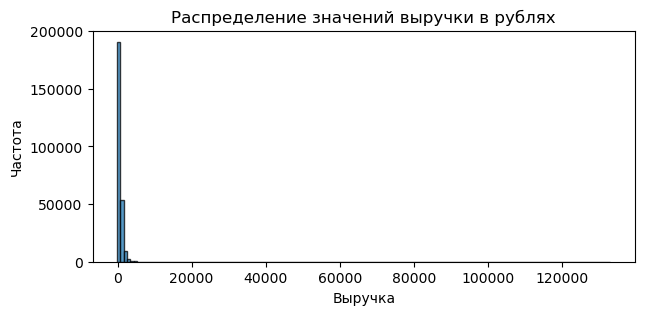

In [18]:
# Построим гистограмму распределения значений столбца 'revenue_rub'

# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 3))

# Строим гистограмму с помощью pandas через plot(kind='hist')
result_df['revenue_rub'].plot(
                kind='hist', # Тип графика - гистограмма
                bins=150, # Устанавливаем количество корзин
                alpha=0.75,
                edgecolor='black',
                rot=0, # Градус вращения подписи по оси Х
)

# Настраиваем оформление графика
plt.title('Распределение значений выручки в рублях')
plt.xlabel('Выручка')
plt.ylabel('Частота')

# Выводим график
plt.show()


Гистограмма распределения не показателельна и явно левоцентрична, что приводит к ожиданию большого количества выбросов. Построим диаграмму размаха исключив выбросы

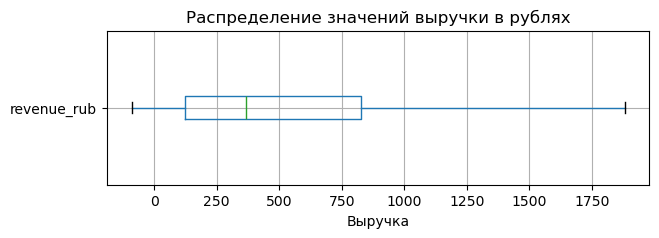

In [19]:
# Построим диаграмму размаха значений столбца 'revenue_rub'

# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 2))

# Строим диаграмму размаха значений в столбце middle_avg_bill без выбросов
result_df.boxplot(column='revenue_rub', vert=False, showfliers=False)

# Добавляем заголовок и метки оси
plt.title('Распределение значений выручки в рублях')
plt.xlabel('Выручка')

# Выводим график
plt.show()

По результатам анализа можно констатировать, что медиана выручки находится в районе 300 рублей. Диапазон выручки по заказу варьируется от -50 до 2000 рублей без учета выбросов. Стоит обратить внимание, что в выручке встречаются отрицательные значения. Вероятно это возвраты или просто некорректные значения. Необходимо оценить объем таких значений и при их незначительном содержании в датасете - исключить.

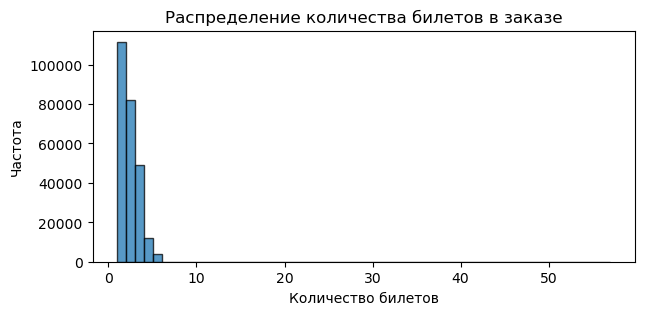

In [20]:
# Построим гистограмму распределения значений столбца 'tickets_count'

# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 3))

# Строим гистограмму с помощью pandas через plot(kind='hist')
result_df['tickets_count'].plot(
                kind='hist', # Тип графика - гистограмма
                bins=55, # Устанавливаем количество корзин
                alpha=0.75,
                edgecolor='black',
                rot=0, # Градус вращения подписи по оси Х
)

# Настраиваем оформление графика
plt.title('Распределение количества билетов в заказе')
plt.xlabel('Количество билетов')
plt.ylabel('Частота')

# Выводим график
plt.show()

Гистограмма распределения не показателельна и также левоцентрична, что приводит к ожиданию большого количества выбросов. Построим диаграмму размаха исключив выбросы

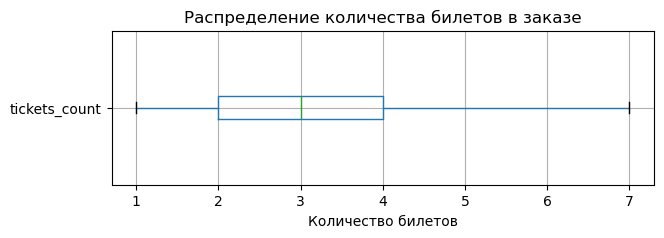

In [21]:
# Построим диаграмму размаха значений столбца 'tickets_count'

# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 2))

# Строим диаграмму размаха значений в столбце middle_avg_bill без выбросов
result_df.boxplot(column='tickets_count', vert=False, showfliers=False)

# Добавляем заголовок и метки оси
plt.title('Распределение количества билетов в заказе')
plt.xlabel('Количество билетов')

# Выводим график
plt.show()

По результатам анализа можно констатировать, что количества билетов в заказе - 3. Диапазон значений варьируется от 1 до 7 рублей без учета выбросов.

In [22]:
# Оценим объем отрицательных значений в столбце 'revenue_rub'
print(result_df.loc[result_df['revenue_rub'] < 0].info())
print()


<class 'pandas.core.frame.DataFrame'>
Index: 353 entries, 252 to 290059
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   user_id                353 non-null    object        
 1   device_type_canonical  353 non-null    object        
 2   order_id               353 non-null    int32         
 3   created_dt_msk         353 non-null    datetime64[ns]
 4   created_ts_msk         353 non-null    datetime64[ns]
 5   currency_code          353 non-null    object        
 6   revenue                353 non-null    float64       
 7   tickets_count          353 non-null    int8          
 8   days_since_prev        321 non-null    float32       
 9   event_id               353 non-null    int32         
 10  event_name             353 non-null    object        
 11  event_type_main        353 non-null    object        
 12  service_name           353 non-null    object        
 13  regio

Исключение 381 строки не скажется на анализе статистики. Строки с отрицательными значениями прибыли можно исключить

In [23]:
print(result_df.info())
print()

# Исключаем из датасета строки с отрицательными значениями 'revenue_rub'
result_df_revenue_positive = result_df.loc[result_df['revenue_rub'] > 0]

# В связи с обнаруженными выбросами в столбце 'revenue_rub', отфильтруем значения по 95 перцентилю. 
df_filtered = result_df_revenue_positive[result_df_revenue_positive['revenue_rub'] <= result_df_revenue_positive['revenue_rub'].quantile(0.95)]

# Проверяем что получилось
print(df_filtered.head(5))
print()
print(df_filtered.info())
print()
print(df_filtered.describe())

<class 'pandas.core.frame.DataFrame'>
Index: 259141 entries, 0 to 290610
Data columns (total 18 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                259141 non-null  object        
 1   device_type_canonical  259141 non-null  object        
 2   order_id               259141 non-null  int32         
 3   created_dt_msk         259141 non-null  datetime64[ns]
 4   created_ts_msk         259141 non-null  datetime64[ns]
 5   currency_code          259141 non-null  object        
 6   revenue                259141 non-null  float64       
 7   tickets_count          259141 non-null  int8          
 8   days_since_prev        237208 non-null  float32       
 9   event_id               259141 non-null  int32         
 10  event_name             259141 non-null  object        
 11  event_type_main        259141 non-null  object        
 12  service_name           259141 non-null  object   

##### Объем отфильтрованных данных 259 141 ---> 243 585. Уменьшение датафрейма на 15 556 строк.

In [24]:
df_filtered.describe()

,order_id,created_dt_msk,created_ts_msk,revenue,tickets_count,days_since_prev,event_id,data,to_rub,revenue_rub
count,2.435850e+05,243585,243585,243585.000000,243585.000000,223508.000000,243585.000000,243585,243585.000000,243585.000000
mean,4.322787e+06,2024-09-03 04:56:20.484019968,2024-09-03 19:53:07.152300544,479.321793,2.710914,3.615052,434580.996071,2024-09-03 04:56:20.484019968,0.191951,482.204411
min,1.000000e+00,2024-06-01 00:00:00,2024-06-01 00:00:42,0.020000,1.000000,0.000000,4436.000000,2024-06-01 00:00:00,0.178486,0.020000
25%,2.172507e+06,2024-08-01 00:00:00,2024-08-01 14:27:33,120.670000,2.000000,0.000000,354322.000000,2024-08-01 00:00:00,0.185991,120.970000
50%,4.318043e+06,2024-09-13 00:00:00,2024-09-13 20:11:14,339.310000,3.000000,0.000000,491001.000000,2024-09-13 00:00:00,0.193262,341.970000
75%,6.481704e+06,2024-10-10 00:00:00,2024-10-10 09:57:14,747.540000,3.000000,1.000000,544890.000000,2024-10-10 00:00:00,0.197843,753.250000
max,8.653108e+06,2024-10-31 00:00:00,2024-10-31 23:59:54,1804.410000,47.000000,148.000000,592325.000000,2024-10-31 00:00:00,0.202773,1804.410000
std,2.493626e+06,NaN,NaN,432.300625,1.144623,12.011771,148203.543071,NaN,0.006166,434.029877


### 3. Промежуточные выводы

Был создан новый столбец, приводящий выручку к единой валюте - российскому рублю. 

Проведена проверка на пропущенные значения. Ввиду вероятной потери ценных для анализа данных, операции с пропусками не проводились. 

Проведено понижение разрядности части данных. 

Проведена оценка необходимости нормализации данных, проведена проверка на явные и неявные дубликаты. Проведено удаление.

Проверено распределение численных данных, необходимых для анализа. Определено большое количество вылетов в численных данных и левоцентричное распределение. Проведена фильтрация по 95 процентилю столбца, характеризующего выручку.

Объем данных исключенных из датафрейма по результатам удаления неявных дубликатов и фильтрации выбросов 290 611 ---> 243 585. Уменьшение датафрейма на 47 026 строк.

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__
    
* В целом с задачей справились, предобработку провели!
    
    
* Хорошо, что сопровождаешь графики заголовком и всеми необходимыми подписями - сразу понятно, что изображено на нем и как его читать!

</div>
<div class="alert alert-block alert-warning">📝
    

__Комментарий от ревьюера №1__

    
* Сейчас ты фиксируешь общие выводы только в конце раздела. Чтобы в работе был понятный сторителлинг, стоит также фиксировать промежуточные свои наблюдения для каждого из шагов: почему мы ничего не стали делать с пропусками и перешли к следующему шагу? Как приняли решение скорректировать тип у тех или иных столбцов? Действительно ли наши категориальные признаки в порядке и не требуют нормализации? Действительно ли в числовых признаках есть выбросы, какова их предполагаемая природа возникновения? Почему мы решили отбросить выбросы в выручке? Почему решили не отбрасывать выбросы в количестве билетов?
    
    
* Для удобства анализа гистограмму для определенного признака стоит строить рядом с боксплотом, чтобы можно было сопоставлять информацию из них. Можно даже создать пользовательскую функцию, которая будет принимать на вход признак и выводить для него сразу два типа визуализации в одном графике ([пример](https://python-graph-gallery.com/24-histogram-with-a-boxplot-on-top-seaborn/)).

    
</div>
<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__

    
* Можно заметить наличие отрицательных значений выручки - возможно, это какие-то возвраты. По-хорошему, их тоже следовало бы исключить, чтобы не завышать количество валидных транзакций на пользователя. Перед этим не забываем проверить, какой процент данных потеряем, не критично ли это.
    

* В задании это не указывается, но по умолчанию важным шагом предварительного анализа и предобработки является проверка на наличие дубликатов, как полных, так и `неполных` (например, если заказ пользователя задублировался в системе, был создан в нескольких экземплярах с разным `id` и временем заказа). Чтобы не искажать статистические расчеты, от таких наблюдений тоже важно избавляться.
    
    
* Выбросы не обработаны. Например в revenue_rub max 18к, при медиане 353
    
    
* После завершения предобработки необходимо отдельным шагом зафиксировать наши потери: сколько наблюдений было до, сколько стало после, сколько потеряли в процентном соотношении. Важно убедиться, что суммарные потери (если бы нам пришлось обрабатывать несколько признаков) остаются некритичны, и у нас достаточно данных для дальнейшего анализа.
    
</div>

<div class="alert alert-info"> <b>Комментарии студента:</b> По несущественным ошибкам - я осознал необходимость фиксации полезной информации "здесь и сейчас" ближе к концу проекта. Но замечание учту, спасибо. Про сразу две гистограммы в одном блоке - спасибо за наводку. Удобно!

Касательно основных замечаний
- Отрицательные значения оценил и отфильтровал.
- Полные дубликаты проверил в начале раздела. До неполных "не допёр". Проверил сейчас, удалил. Хотя честно говоря это было довольно непросто
- Теперь обработаны :)
- Добавил эту информацию
</div>

## Создание профиля пользователя

### 1. Построение профиля пользователя
Для каждого пользователя необходимо найти:
- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле event_type_main );
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами
- Добавить два бинарных признака:
    - is_two — совершил ли пользователь 2 и более заказа;
    - is_five — совершил ли пользователь 5 и более заказов.Создание профиля пользователя

In [25]:
# Сортируем с добавлением order_id для стабильности при одинаковых timestamps
df_sorted = df_filtered.sort_values(['user_id', 'created_dt_msk', 'order_id'])

# Агрегируем все метрики в одной операции группировки
final_profile = df_sorted.groupby('user_id').agg(
    first_order_date=('created_dt_msk', 'min'), 
    last_order_date=('created_dt_msk', 'max'),    
    first_device=('device_type_canonical', 'first'),
    first_region=('region_name', 'first'),
    first_service_name=('service_name', 'first'),
    first_event_type=('event_type_main', 'first'),
    total_orders=('order_id', 'count'),
    avg_revenue=('revenue_rub', 'mean'),
    avg_tickets=('tickets_count', 'mean'),
    avg_days_since_prev=('days_since_prev', 'mean')
).reset_index()

# Создаём бинарные признаки
final_profile['is_two'] = (final_profile['total_orders'] >= 2).astype(bool)
final_profile['is_five'] = (final_profile['total_orders'] >= 5).astype(bool)

# Проверяем, что получилось
print(final_profile.head(10))
print()
print(final_profile.info())

           user_id first_order_date last_order_date first_device  \
0  0002849b70a3ce2       2024-08-20      2024-08-20       mobile   
1  0005ca5e93f2cf4       2024-07-23      2024-10-06       mobile   
2  000898990054619       2024-07-13      2024-10-23       mobile   
3  00096d1f542ab2b       2024-08-15      2024-08-15      desktop   
4  000a55a418c128c       2024-09-29      2024-10-15       mobile   
5  000cf0659a9f40f       2024-06-20      2024-06-21       mobile   
6  00147c9209d45d3       2024-06-25      2024-06-25       mobile   
7  00199a573901564       2024-06-17      2024-06-17       mobile   
8  001e7037d013f0f       2024-07-04      2024-09-29       mobile   
9  0020c5654c92ec1       2024-07-02      2024-07-02       mobile   

           first_region  first_service_name first_event_type  total_orders  \
0    Каменевский регион        Край билетов            театр             1   
1    Каменевский регион           Мой билет         выставки             2   
2  Североярская о

<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__
    
    
Твой способ определения значений категориальных характеристик первого заказа не надежен. Если у пользователя было несколько заказов в первый день, присоединение значений по дате приведет к дублированию записей о пользователе.
    
В данном случае необходимо группировать и использовать метод агрегации `first`, он берет значение первой записи. Как раз ввиду его использования и следовало отсортировать заказы по времени.
    
Обрати внимание, что с учетом данной правки могут потребоваться и корректировки в шагах ниже.
    
</div>    

<div class="alert alert-block alert-warning">📝
    

__Комментарий от ревьюера №1__
    
* Также есть довольно удобный метод [assign](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.assign.html), позволяющий дополнять таблицу новыми рассчитанными столбцами.
    
    Тогда создание всего профиля можно будет записать красивым и удобным по структуре кодом.

    <details> <summary> <span style='color:blue' > Развернуть подробнее. </span> </summary>

    ```python
    profiles = (df
            # В начале сортируем данные по дате совершения заказа, что найти первые признаки:
            .sort_values(by='order_ts')
            # Затем группируем по номеру пользователя и агрегируем данные:
            .groupby('user_id')
            .agg(
                # Находим первую и последнюю даты заказа:
                first_order_dt=('order_dt','min'),
                last_order_dt=('order_dt','max'),
                # Находим устройства, регион, название билетного партнера и тип мероприятия первого заказа:
                first_device=('device_type_canonical','first'),
                first_region_name=('region_name','first'),
                first_service_name=('service_name','first'),
                first_event_type=('event_type_main','first'),
                # Подсчитваем количество заказов:
                total_orders=('order_id','nunique'),
                # Считаем статистику по заказам: средняя стоимость заказа, среднее количество билетов:
                avg_revenue_rub=('revenue_rub','mean'),
                avg_tickets_count=('tickets_count','mean'),
                # Считаем среднее количество дней между покупками:
                avg_days_since_prev=('days_since_prev','mean')
            )
            # Создаем два признака: совершил ли пользователь 2 / 5 и более заказов:
            .assign(
                is_two = lambda x: x['total_orders'] >= 2,
                is_five = lambda x: x['total_orders'] >= 5
            )
            .reset_index()
    )
    ```
    </details>

    
* Согласно стандартам оформления кода не стоит делать строики длиной более 79 символов, это портит его читаемость, вынуждает прокручивать ячейку.
    
</div>

<div class="alert alert-info"> <b>Комментарии студента:</b> Спасибо за подсказку с методом assign. Учту её в будущем. Я действительно местами растягиваю строку и забываю про читаемость кода.

Исправил код, но немного по-своему. :)
</div>

### 2. Изучение профиля на репрезентативность и аномалии

Используя данные о профилях пользователей, рассчитаем:
- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов.

Также изучим статистические показатели:
- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.

In [26]:
# Считаем общее число пользователей в выборке
users_sum = final_profile.shape[0]
print(f'Общее число пользователей в выборке: {users_sum}')

# Считаем среднюю выручку с одного заказа
mean_revenue = final_profile['avg_revenue'].mean()
print(f'Средняя выручка с одного заказа: {mean_revenue}')

# Считаем долю пользователей, совершивших 2 заказа 
is_two_sum = final_profile['is_two'].sum() / final_profile['is_two'].count()
print(f'Доля пользователей, совершивших 2 заказа: {is_two_sum}')

# Считаем долю пользователей, совершивших 5 заказов 
is_five_sum = final_profile['is_five'].sum() / final_profile['is_five'].count()
print(f'Доля пользователей, совершивших 5 заказов: {is_five_sum}')

Общее число пользователей в выборке: 21028
Средняя выручка с одного заказа: 512.4180695925821
Доля пользователей, совершивших 2 заказа: 0.5853623739775538
Доля пользователей, совершивших 5 заказов: 0.2578466806163211


In [27]:
# Считаем обцее число заказов 
order_sum = final_profile['total_orders'].sum()
print(f'Обцее число заказов: {order_sum}')

# Считаем среднее число билетов в заказе 
tickets__mean = final_profile['avg_tickets'].mean()
print(f'Среднее число билетов в заказе: {tickets__mean}')

# Считаем среднее количество дней между пропусками
days_since_prev_mean_mean = final_profile['avg_days_since_prev'].mean()
print(f'Среднее количество дней между пропусками: {days_since_prev_mean_mean}')

Обцее число заказов: 243585
Среднее число билетов в заказе: 2.705980765246847
Среднее количество дней между пропусками: 18.178373336791992


Изучим каждый статистический показатель подробнее

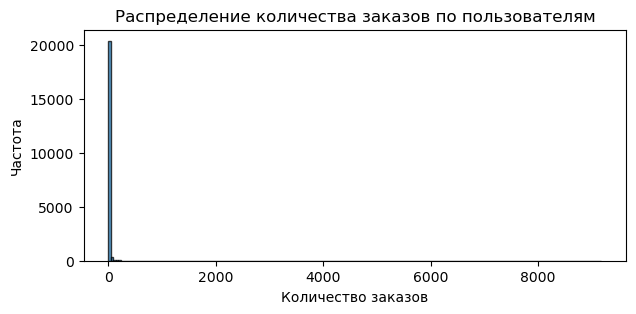

In [28]:
# Построим гистограмму распределения значений столбца 'order_id_count'

# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 3))

# Строим гистограмму с помощью pandas через plot(kind='hist')
final_profile['total_orders'].plot(
                kind='hist', # Тип графика - гистограмма
                bins=200, # Устанавливаем количество корзин
                alpha=0.75,
                edgecolor='black',
                rot=0, # Градус вращения подписи по оси Х
)

# Настраиваем оформление графика
plt.title('Распределение количества заказов по пользователям')
plt.xlabel('Количество заказов')
plt.ylabel('Частота')

# Выводим график
plt.show()

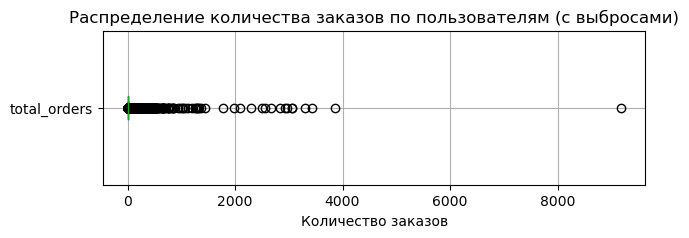

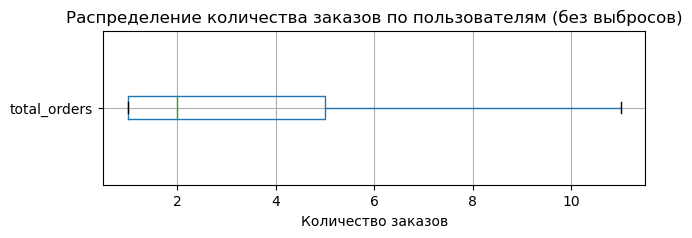

In [29]:
# Построим диаграмму размаха значений столбца 'order_id_count'

# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 2))

# Строим диаграмму размаха значений в столбце middle_avg_bill с выбросами
final_profile.boxplot(column='total_orders', vert=False, showfliers=True)

# Добавляем заголовок и метки оси
plt.title('Распределение количества заказов по пользователям (с выбросами)')
plt.xlabel('Количество заказов')

# Выводим график
plt.show()



# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 2))

# Строим диаграмму размаха значений в столбце middle_avg_bill без выбросов
final_profile.boxplot(column='total_orders', vert=False, showfliers=False)

# Добавляем заголовок и метки оси
plt.title('Распределение количества заказов по пользователям (без выбросов)')
plt.xlabel('Количество заказов')

# Выводим график
plt.show()

График расределения количества заказов по пользователям носит левоцентричный характер. Исходя из результатов построения диаграммы "ящик с усами" стоит сделать фильтрацию датафрейма по 99 процентилю.

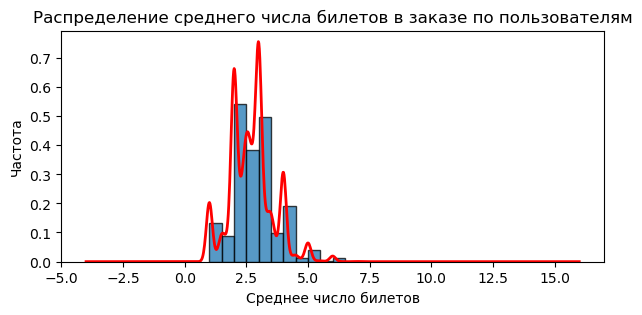

In [30]:
# Построим гистограмму распределения значений столбца 'tickets_count_mean'

# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 3))

# Строим гистограмму с помощью pandas через plot(kind='hist')
final_profile['avg_tickets'].plot(
                kind='hist', # Тип графика - гистограмма
                bins=20, # Устанавливаем количество корзин
                alpha=0.75,
                edgecolor='black',
                density=True,
                rot=0 # Градус вращения подписи по оси Х
)

# Добавляем линию KDE поверх гистограммы
final_profile['avg_tickets'].plot(
                kind='kde', 
                color='red',      # Цвет линии
                linewidth=2       # Толщина линии
)

# Настраиваем оформление графика
plt.title('Распределение среднего числа билетов в заказе по пользователям')
plt.xlabel('Среднее число билетов')
plt.ylabel('Частота')

# Выводим график
plt.show()

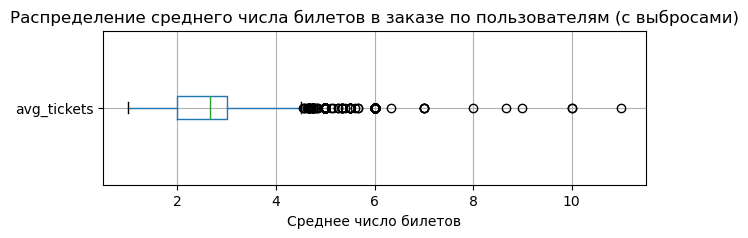

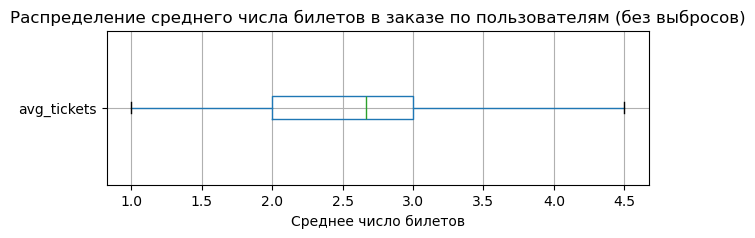

In [31]:
# Построим диаграмму размаха значений столбца 'tickets_count_mean'

# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 2))

# Строим диаграмму размаха значений в столбце middle_avg_bill с выбросами
final_profile.boxplot(column='avg_tickets', vert=False, showfliers=True)

# Добавляем заголовок и метки оси
plt.title('Распределение среднего числа билетов в заказе по пользователям (с выбросами)')
plt.xlabel('Среднее число билетов')

# Выводим график
plt.show()



# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 2))

# Строим диаграмму размаха значений в столбце middle_avg_bill без выбросов
final_profile.boxplot(column='avg_tickets', vert=False, showfliers=False)

# Добавляем заголовок и метки оси
plt.title('Распределение среднего числа билетов в заказе по пользователям (без выбросов)')
plt.xlabel('Среднее число билетов')

# Выводим график
plt.show()

Распределение значений среднего числа билетов по пользователям не характеризуются гигантскими выбросами, но график распределения также не описывает нормальное распределение, а имеет несколько пиков, что в такой характеристике допустимо. Исходя из результатов распределения, фильтрация данных по данному параметру избыточна.

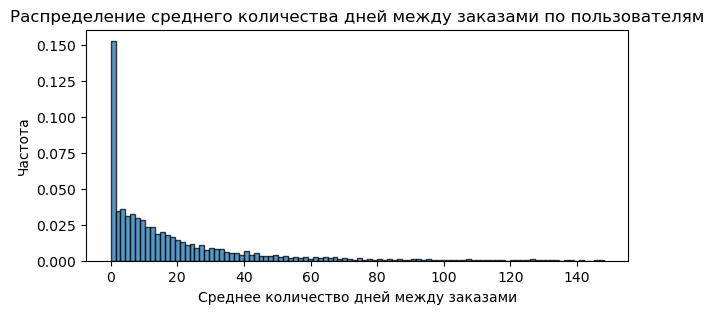

In [32]:
# Построим гистограмму распределения значений столбца 'days_since_prev_mean'

# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 3))

# Строим гистограмму с помощью pandas через plot(kind='hist')
final_profile['avg_days_since_prev'].plot(
                kind='hist', # Тип графика - гистограмма
                bins=100, # Устанавливаем количество корзин
                alpha=0.75,
                edgecolor='black',
                density=True,
                rot=0 # Градус вращения подписи по оси Х
)

# Настраиваем оформление графика
plt.title('Распределение среднего количества дней между заказами по пользователям')
plt.xlabel('Среднее количество дней между заказами')
plt.ylabel('Частота')

# Выводим график
plt.show()

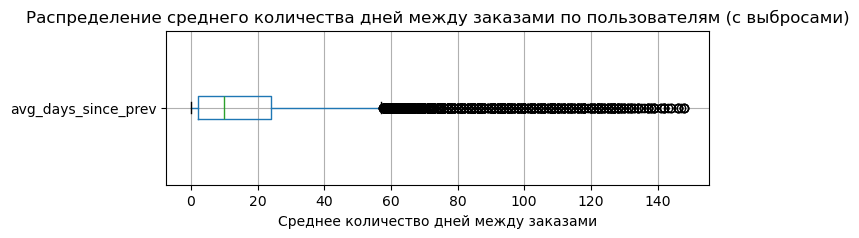

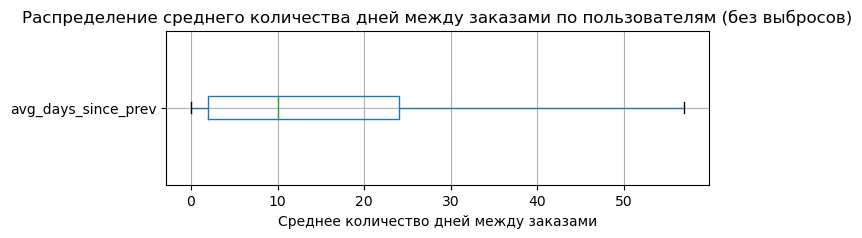

In [33]:
# Построим диаграмму размаха значений столбца 'days_since_prev_mean'

# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 2))

# Строим диаграмму размаха значений в столбце middle_avg_bill с выбросами
final_profile.boxplot(column='avg_days_since_prev', vert=False, showfliers=True)

# Добавляем заголовок и метки оси
plt.title('Распределение среднего количества дней между заказами по пользователям (с выбросами)')
plt.xlabel('Среднее количество дней между заказами')

# Выводим график
plt.show()


# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 2))

# Строим диаграмму размаха значений в столбце middle_avg_bill без выбросов
final_profile.boxplot(column='avg_days_since_prev', vert=False, showfliers=False)

# Добавляем заголовок и метки оси
plt.title('Распределение среднего количества дней между заказами по пользователям (без выбросов)')
plt.xlabel('Среднее количество дней между заказами')

# Выводим график
plt.show()

График расределения среднего количества дней между заказами по пользователям носит строго левоцентричный характер. Исходя из результатов построения диаграммы "ящик с усами" стоит сделать фильтрацию датафрейма по 95 процентилю. Однако объем отфильтрованных данных в таком случае составить почти половину от исходного датасета, поэтому фильтровать не будем.

In [34]:
# В связи с обнаруженными выбросами в столбце 'order_id_count', отфильтруем значения по 99 перцентилю. 
final_profile_filtered = final_profile[final_profile['total_orders'] <= final_profile['total_orders'].quantile(0.99)]

# Проверяем что получилось
print(final_profile_filtered)
print()
print(final_profile_filtered.info())

               user_id first_order_date last_order_date first_device  \
0      0002849b70a3ce2       2024-08-20      2024-08-20       mobile   
1      0005ca5e93f2cf4       2024-07-23      2024-10-06       mobile   
2      000898990054619       2024-07-13      2024-10-23       mobile   
3      00096d1f542ab2b       2024-08-15      2024-08-15      desktop   
4      000a55a418c128c       2024-09-29      2024-10-15       mobile   
...                ...              ...             ...          ...   
21023  fff13b79bd47d7c       2024-07-16      2024-10-31       mobile   
21024  fff32fc9ad0f9f6       2024-08-15      2024-10-28      desktop   
21025  fffcd3dde79eb2c       2024-06-20      2024-10-30      desktop   
21026  fffeeb3c120cf0b       2024-09-24      2024-09-24      desktop   
21027  ffff00725179321       2024-09-25      2024-09-25       mobile   

               first_region  first_service_name first_event_type  \
0        Каменевский регион        Край билетов            театр   

In [35]:
final_profile_filtered.describe()

,first_order_date,last_order_date,total_orders,avg_revenue,avg_tickets,avg_days_since_prev
count,20818,20818,20818.000000,20818.000000,20818.000000,12362.000000
mean,2024-08-11 22:49:55.792102912,2024-09-18 17:54:21.754251264,5.646940,512.756298,2.706068,18.478773
min,2024-06-01 00:00:00,2024-06-01 00:00:00,1.000000,0.070000,1.000000,0.000000
25%,2024-06-28 00:00:00,2024-08-25 00:00:00,1.000000,217.467500,2.000000,2.493644
50%,2024-08-11 00:00:00,2024-10-03 00:00:00,2.000000,453.130714,2.666667,10.279221
75%,2024-09-24 00:00:00,2024-10-22 00:00:00,5.000000,725.940000,3.000000,24.500000
max,2024-10-31 00:00:00,2024-10-31 00:00:00,131.000000,1804.410000,11.000000,148.000000
std,NaN,NaN,12.300092,372.206850,0.901531,23.760071


In [36]:
# Считаем общее число пользователей в выборке
users_sum = final_profile_filtered.shape[0]
print(f'Общее число пользователей в выборке: {users_sum}')

# Считаем среднюю выручку с одного заказа
mean_revenue = final_profile_filtered['avg_revenue'].mean()
print(f'Средняя выручка с одного заказа: {mean_revenue}')

# Считаем долю пользователей, совершивших 2 заказа 
is_two_sum = final_profile_filtered['is_two'].sum() / final_profile_filtered['is_two'].count()
print(f'Доля пользователей, совершивших 2 заказа: {is_two_sum}')

# Считаем долю пользователей, совершивших 5 заказов 
is_five_sum = final_profile_filtered['is_five'].sum() / final_profile_filtered['is_five'].count()
print(f'Доля пользователей, совершивших 5 заказов: {is_five_sum}')

# Считаем обцее число заказов 
order_sum = final_profile_filtered['total_orders'].sum()
print(f'Обцее число заказов: {order_sum}')

# Считаем среднее число билетов в заказе 
tickets__mean = final_profile_filtered['avg_tickets'].mean()
print(f'Среднее число билетов в заказе: {tickets__mean}')

# Считаем среднее количество дней между пропусками
days_since_prev_mean_mean = final_profile_filtered['avg_days_since_prev'].mean()
print(f'Среднее количество дней между пропусками: {days_since_prev_mean_mean}')

Общее число пользователей в выборке: 20818
Средняя выручка с одного заказа: 512.7562979143773
Доля пользователей, совершивших 2 заказа: 0.581179748294745
Доля пользователей, совершивших 5 заказов: 0.2503602651551542
Обцее число заказов: 117558
Среднее число билетов в заказе: 2.706067589619372
Среднее количество дней между пропусками: 18.47877311706543


<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__
    
Тут аналогично, выбрсоы не обработаны


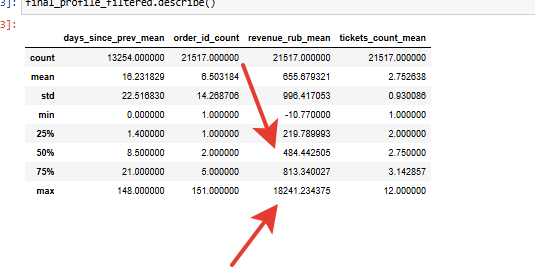

<div class="alert alert-info"> <b>Комментарии студента:</b> Это была скорее ошибка, перетянутая из предыдущего раздела. Сейчас все ОК.
</div>

### 3. Промежуточный вывод по результатам построения профиля пользователя

Были построены и объединены сводные таблицы, сформировавшие по итогу профиль пользователя. Изучены статистические показатели. Данные отфильтрованы с 21 735 строк до 21 517 и приведены к релевантному состоянию. Объем отфильтрованных данных составил примерно 1 %.

Итоговые статистические показатели в получившемся датафрейме:

- Общее число пользователей в выборке: 21517
- Средняя выручка с одного заказа: 655.6793339889493
- Доля пользователей, совершивших 2 заказа: 0.6137007947204536
- Доля пользователей, совершивших 5 заказов: 0.2841474183203978
- Обцее число заказов: 139929
- Среднее число билетов в заказе: 2.75263800488627
- Среднее количество дней между пропусками: 16.231830596923828

## Исследовательский анализ данных

### 1. Исследование признаков первого заказа и их связи с возвращением на платформу

#### 1.1. Изучение распределения пользователей по признакам.

Сгруппируем пользователей:
- по типу их первого мероприятия;
- по типу устройства, с которого совершена первая покупка;
- по региону проведения мероприятия из первого заказа;
- по билетному оператору, продавшему билеты на первый заказ.

Подсчитаем общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака.

Ответим на вопрос: равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей?

In [37]:
# Группируем и считаем пользователей по типу их первого мероприятия
grouped1 = final_profile_filtered.groupby('first_event_type')['user_id'].count().sort_values(ascending=False)

# Создаем датафрейм
pivot_event_type_main_grouped = pd.DataFrame({'count': grouped1, 'share': grouped1 / grouped1.sum()}).reset_index()

print(pivot_event_type_main_grouped)

  first_event_type  count     share
0         концерты   8942  0.429532
1           другое   5248  0.252090
2            театр   4258  0.204535
3          стендап   1109  0.053271
4            спорт    746  0.035834
5         выставки    423  0.020319
6             ёлки     92  0.004419


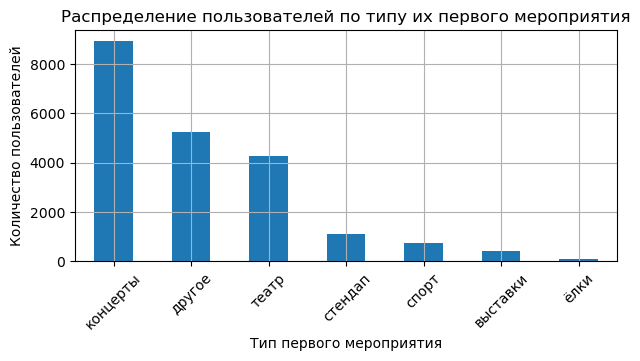

In [38]:
# Построим график столбчатой диаграммы

# Сортируем по убыванию
grouped1 = grouped1.sort_values(ascending=False)

grouped1.plot(kind='bar',
               title=f'Распределение пользователей по типу их первого мероприятия',
               legend=False,
               ylabel='Количество пользователей',
               xlabel='Тип первого мероприятия',
               rot=45,
               figsize=(7, 3))
plt.grid()

# Выводим график
plt.show()

In [39]:
# Группируем и считаем пользователей по типу устройства, с которого совершена первая покупка
grouped2 = final_profile_filtered.groupby('first_device')['user_id'].count().sort_values(ascending=False)

# Создаем датафрейм
pivot_device_type_canonical_grouped = pd.DataFrame({'count': grouped2, 'share': grouped2 / grouped2.sum()}).reset_index()

print(pivot_device_type_canonical_grouped)

  first_device  count     share
0       mobile  17286  0.830339
1      desktop   3532  0.169661


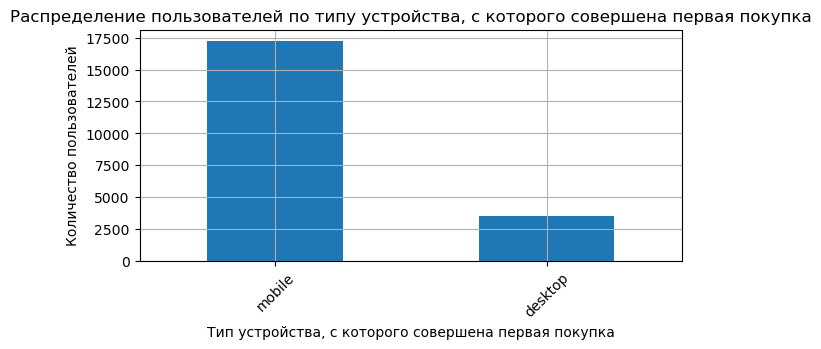

In [40]:
# Построим график столбчатой диаграммы

# Сортируем по убыванию
grouped2 = grouped2.sort_values(ascending=False)

grouped2.plot(kind='bar',
               title=f'Распределение пользователей по типу устройства, с которого совершена первая покупка',
               legend=False,
               ylabel='Количество пользователей',
               xlabel='Тип устройства, с которого совершена первая покупка',
               rot=45,
               figsize=(7, 3))
plt.grid()

# Выводим график
plt.show()

In [41]:
# Группируем и считаем пользователей по региону проведения мероприятия из первого заказа
grouped3 = final_profile_filtered.groupby('first_region')['user_id'].count().sort_values(ascending=False)

# Создаем датафрейм
pivot_region_name_grouped = pd.DataFrame({'count': grouped3, 'share': grouped3 / grouped3.sum()}).reset_index()

print(pivot_region_name_grouped)

                first_region  count     share
0         Каменевский регион   6905  0.331684
1       Североярская область   3824  0.183687
2        Широковская область   1216  0.058411
3           Озернинский край    642  0.030839
4       Малиновоярский округ    493  0.023681
..                       ...    ...       ...
76            Залесский край      2  0.000096
77       Тихогорская область      2  0.000096
78         Верхозёрский край      1  0.000048
79  Сосноводолинская область      1  0.000048
80        Яснопольский округ      1  0.000048

[81 rows x 3 columns]


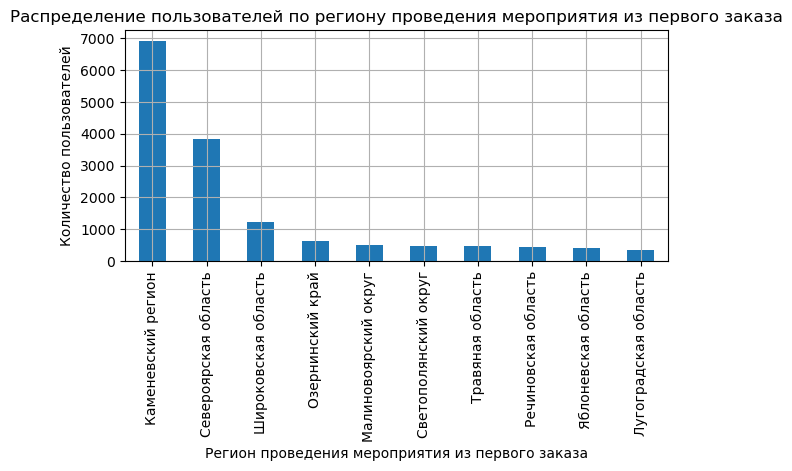

In [42]:
# Построим график столбчатой диаграммы (Для наглядности - топ 10)

# Сортируем по убыванию
grouped3 = grouped3.sort_values(ascending=False)

grouped3.head(10).plot(kind='bar',
               title=f'Распределение пользователей по региону проведения мероприятия из первого заказа',
               legend=False,
               ylabel='Количество пользователей',
               xlabel='Регион проведения мероприятия из первого заказа',
               rot=90,
               figsize=(7, 3))
plt.grid()

# Выводим график
plt.show()

In [43]:
# Группируем и считаем пользователей по билетному оператору, продавшему билеты на первый заказ
grouped4 = final_profile_filtered.groupby('first_service_name')['user_id'].count().sort_values(ascending=False)

# Создаем датафрейм
pivot_service_name_grouped = pd.DataFrame({'count': grouped4, 'share': grouped4 / grouped4.sum()}).reset_index()

print(pivot_service_name_grouped)

        first_service_name  count     share
0       Билеты без проблем   4795  0.230330
1              Лови билет!   2840  0.136420
2            Билеты в руки   2580  0.123931
3                Мой билет   2540  0.122010
4                  Облачко   2204  0.105870
5           Весь в билетах   1213  0.058267
6            Лучшие билеты   1198  0.057546
7                Прачечная    598  0.028725
8             Край билетов    436  0.020943
9             Дом культуры    336  0.016140
10                  Яблоко    324  0.015563
11             Тебе билет!    309  0.014843
12  Городской дом культуры    224  0.010760
13                Мир касс    211  0.010135
14             За билетом!    209  0.010039
15             Show_ticket    162  0.007782
16             Быстробилет    162  0.007782
17          Выступления.ру    100  0.004804
18               Восьмёрка     88  0.004227
19          Быстрый кассир     57  0.002738
20           Crazy ticket!     47  0.002258
21            Радио ticket     3

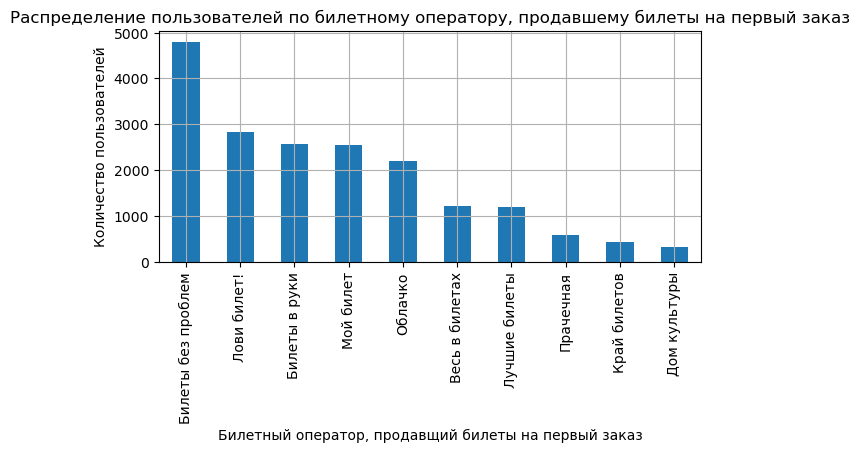

In [44]:
# Построим график столбчатой диаграммы (Для наглядности - топ 10)

# Сортируем по убыванию
grouped4 = grouped4.sort_values(ascending=False)

grouped4.head(10).plot(kind='bar',
               title=f'Распределение пользователей по билетному оператору, продавшему билеты на первый заказ',
               legend=False,
               ylabel='Количество пользователей',
               xlabel='Билетный оператор, продавщий билеты на первый заказ',
               rot=90,
               figsize=(7, 3))
plt.grid()

# Выводим график
plt.show()

Пользователи распределены по сегментам неравномерно. 

В основном первый заказ пользователи совершают с мобильного устройства. Вероятно стоит подумать над маркетинговыми схемами, стимулирующими пользователей совершать первый заказ с ПК.

В основном в качестве первого заказа пользователи активно приобретают билеты на концерты, театр и "другое". Реже всего - на ёлки. С учетом такогог распределения, вероятно стоит конкретизировать информацию в данных и детализировать понятие "другое", чтобы понять что особенно привлекает пользователей. Также можно подумать над маркетинговыми схемами, стимулирующими приобретать билеты на ёлки и другие малоохваченные мероприятия.

В явных лидерах по первому заказу находятся 2 района: Каменевский район и Североярская область. Либо там нет конкурентов, либо стоит изучить их опыт более детально и поработать над стимулированием пользователей других регионов. Особенно из регионов: Сосноводолинская область и Яснопольский округ.

Наиболее активный оператор,Ю продающий билеты на первый заказ понятен, но за ним равномерно следует группа из еще 4-х операторов, а операторы с 5 по 32 места почти не участвуют в формировании статистики. Стоит подумать, насколько вообще стоит с ними взаимодействовать в дальнейшем.

Есть выраженные «точки входа» — сегменты с наибольшим числом пользователей:

- по типу первого мероприятия - **концерты**
- по типу устройства, с которого совершена первая покупка - **mobile**
- по региону проведения мероприятия из первого заказа - **Каменевский район**
- по билетному оператору, продавшему билеты на первый заказ - **Билеты без проблем**

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

По результатам всё верно
    
    
<div class="alert alert-block alert-warning">📝
    

__Комментарий от ревьюера №1__
    
* Можно создать пользовательскую функцию, чтобы не прописывать практически один и тот же код несколько раз  
    
        def segment_summary(df, column):
        seg = (df.groupby(column).agg(users_count=('user_id', 'nunique')) .reset_index().sort_values('users_count', ascending=False))
        seg['users_share'] = (seg['users_count'] / seg['users_count'].sum() *100)
        seg['users_share'] = seg['users_share'].round(2)
        return seg

    
* Визуализировать полученные данные,     
    
* По выводам хорошо бы показать общую картину: как распределяются пользователи по сегментам, какие группы преобладают, какие встречаются реже и почему так может быть. А уже после этого привести конкретные значения - как подтверждение своих наблюдений.  

<div class="alert alert-info"> <b>Комментарии студента:</b> Спасибо за подсказку с функцией. Это абсолютно логично. Учту в будущем.
    Касательно визуализации - добавил
    Касательно выводов - поправил
</div>

#### 1.2. Анализ возвратов пользователей:
Для каждого сегмента вычислим долю пользователей, совершивших два и более заказа.

Визуализируем результат подходящим графиком. 

Ответим на вопросы:
- Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
- Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?

In [45]:
# Вычисляем долю пользователей, совершивших два и более заказа для сегмента пользователей по типу их первого мероприятия
pivot_event_type_main_grouped_is_two = pd.DataFrame({
    'count_True': final_profile_filtered.groupby('first_event_type')['is_two'].sum(), 
    'share_True': final_profile_filtered.groupby('first_event_type')['is_two'].sum() / final_profile_filtered.groupby('first_event_type')['is_two'].count(),
    'users': final_profile_filtered.groupby('first_event_type')['is_two'].count()})

print(pivot_event_type_main_grouped_is_two.sort_values(by='count_True', ascending=False))

                  count_True  share_True  users
first_event_type                               
концерты                5177    0.578953   8942
другое                  2983    0.568407   5248
театр                   2595    0.609441   4258
стендап                  643    0.579802   1109
спорт                    389    0.521448    746
выставки                 263    0.621749    423
ёлки                      49    0.532609     92


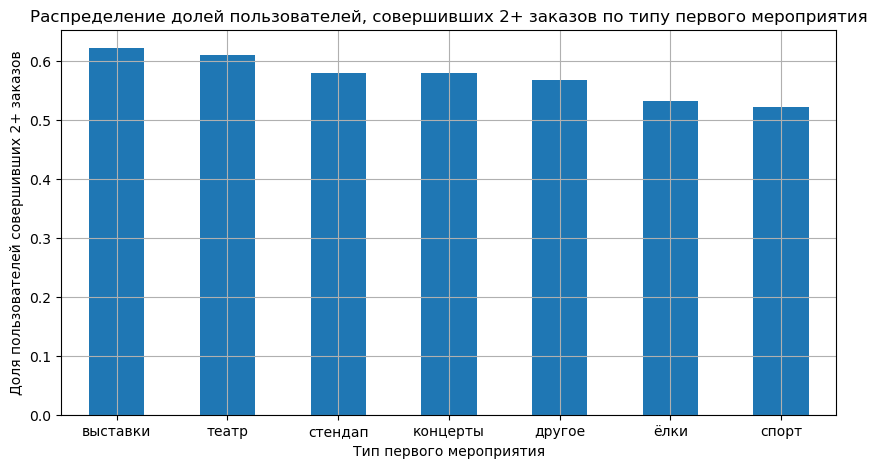

In [46]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(10, 5))

# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
pivot_event_type_main_grouped_is_two['share_True'].sort_values(ascending=False).plot(
               kind = 'bar', # Тип графика - столбчатая диаграмма
               rot = 0, # Градус вращения подписи по оси Х
               legend = False, # Выключаем легенду
               grid = True,
               title=f'Распределение долей пользователей, совершивших 2+ заказов по типу первого мероприятия'
)

# Настраиваем оформление графика
plt.xlabel('Тип первого мероприятия')
plt.ylabel('Доля пользователей совершивших 2+ заказов')

# Выводим график
plt.show()

In [47]:
# Вычисляем долю пользователей, совершивших два и более заказа для сегмента пользователей по типу устройства, с которого совершена первая покупка
pivot_device_type_canonical_is_two = pd.DataFrame({
    'count_True': final_profile_filtered.groupby('first_device')['is_two'].sum(), 
    'share_True': final_profile_filtered.groupby('first_device')['is_two'].sum() / final_profile_filtered.groupby('first_device')['is_two'].count(),
    'users': final_profile_filtered.groupby('first_device')['is_two'].count() 
    })

print(pivot_device_type_canonical_is_two.sort_values(by='count_True', ascending=False))

              count_True  share_True  users
first_device                               
mobile              9951    0.575668  17286
desktop             2148    0.608154   3532


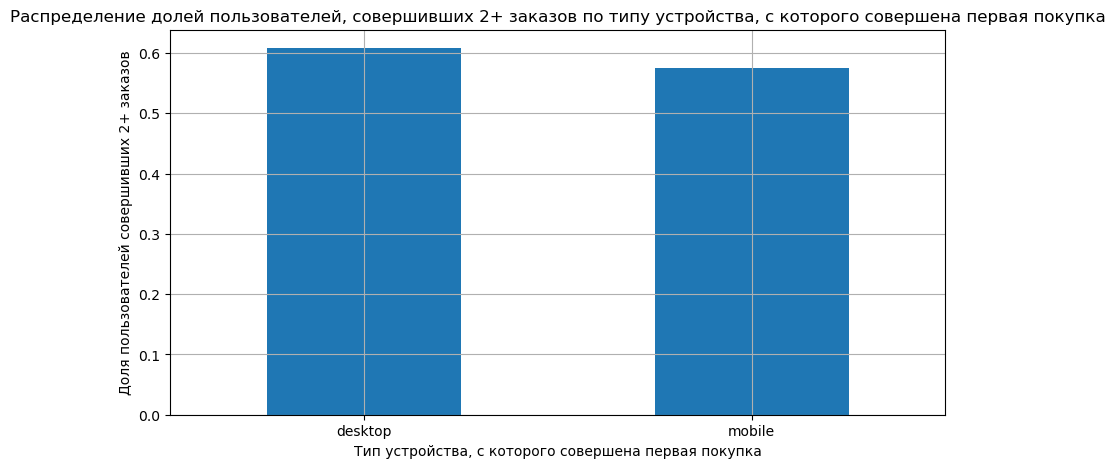

In [48]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(10, 5))

# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
pivot_device_type_canonical_is_two['share_True'].sort_values(ascending=False).plot(
               kind = 'bar', # Тип графика - столбчатая диаграмма
               rot = 0, # Градус вращения подписи по оси Х
               legend = False, # Выключаем легенду
               grid = True,
               title=f'Распределение долей пользователей, совершивших 2+ заказов по типу устройства, с которого совершена первая покупка'
)

# Настраиваем оформление графика
plt.xlabel('Тип устройства, с которого совершена первая покупка')
plt.ylabel('Доля пользователей совершивших 2+ заказов')

# Выводим график
plt.show()

In [49]:
# Вычисляем долю пользователей, совершивших два и более заказа для сегмента пользователей по региону проведения мероприятия из первого заказа
pivot_region_name_is_two = pd.DataFrame({
    'count_True': final_profile_filtered.groupby('first_region')['is_two'].sum(), 
    'share_True': final_profile_filtered.groupby('first_region')['is_two'].sum() / final_profile_filtered.groupby('first_region')['is_two'].count(),
    'users': final_profile_filtered.groupby('first_region')['is_two'].count(), 
    })

print(pivot_region_name_is_two.sort_values(by='count_True', ascending=False))

                          count_True  share_True  users
first_region                                           
Каменевский регион              4102    0.594062   6905
Североярская область            2348    0.614017   3824
Широковская область              743    0.611020   1216
Озернинский край                 315    0.490654    642
Светополянский округ             303    0.632568    479
...                              ...         ...    ...
Теплоозёрский округ                1    0.333333      3
Островогорский округ               1    0.250000      4
Крутоводский регион                0    0.000000      3
Сосноводолинская область           0    0.000000      1
Яснопольский округ                 0    0.000000      1

[81 rows x 3 columns]


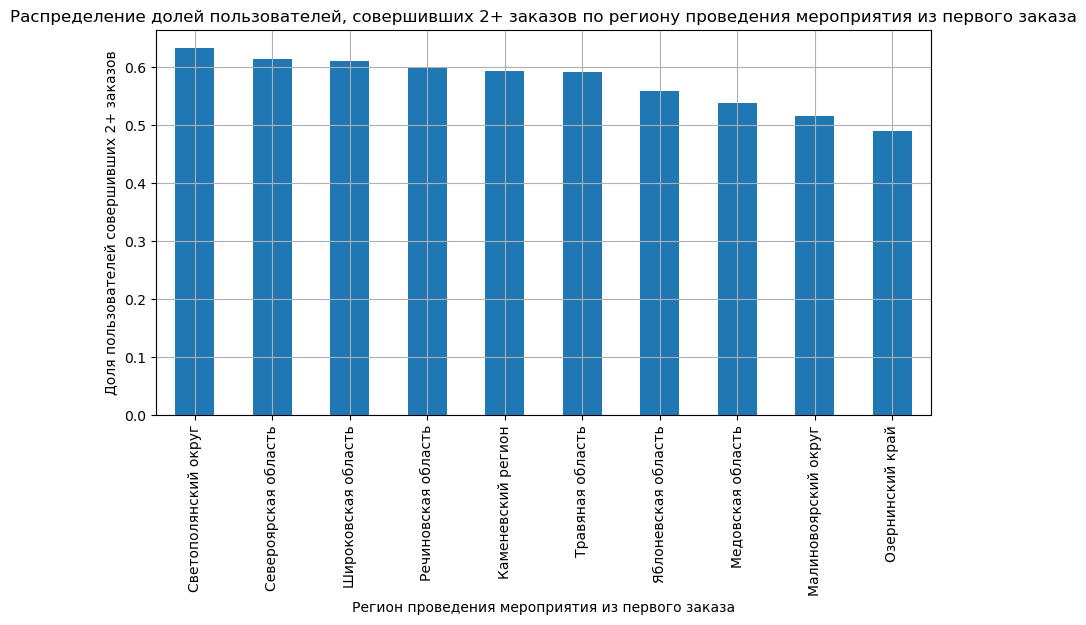

In [50]:
# Создаем урезанный датафрейм в соответствии с условием
pivot_region_name_is_two_cut = pivot_region_name_is_two.sort_values(by='users', ascending=False).head(10)

# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(10, 5))

# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
pivot_region_name_is_two_cut['share_True'].sort_values(ascending=False).plot(
               kind = 'bar', # Тип графика - столбчатая диаграмма
               rot = 90, # Градус вращения подписи по оси Х
               legend = False, # Выключаем легенду
               grid = True,
               title=f'Распределение долей пользователей, совершивших 2+ заказов по региону проведения мероприятия из первого заказа'
)

# Настраиваем оформление графика
plt.xlabel('Регион проведения мероприятия из первого заказа')
plt.ylabel('Доля пользователей совершивших 2+ заказов')

# Выводим график
plt.show()

In [51]:
# Вычисляем долю пользователей, совершивших два и более заказа для сегмента пользователей по билетному оператору, продавшему билеты на первый заказ
pivot_service_name_is_two = pd.DataFrame({
    'count_True': final_profile_filtered.groupby('first_service_name')['is_two'].sum(), 
    'share_True': final_profile_filtered.groupby('first_service_name')['is_two'].sum() / final_profile_filtered.groupby('first_service_name')['is_two'].count(),
    'users': final_profile_filtered.groupby('first_service_name')['is_two'].count(), 
    })

print(pivot_service_name_is_two.sort_values(by='count_True', ascending=False))

                        count_True  share_True  users
first_service_name                                   
Билеты без проблем            2740    0.571429   4795
Лови билет!                   1665    0.586268   2840
Билеты в руки                 1559    0.604264   2580
Мой билет                     1418    0.558268   2540
Облачко                       1267    0.574864   2204
Весь в билетах                 707    0.582852   1213
Лучшие билеты                  692    0.577629   1198
Прачечная                      362    0.605351    598
Край билетов                   275    0.630734    436
Дом культуры                   205    0.610119    336
Тебе билет!                    173    0.559871    309
Яблоко                         166    0.512346    324
Мир касс                       130    0.616114    211
Городской дом культуры         128    0.571429    224
За билетом!                    119    0.569378    209
Show_ticket                    100    0.617284    162
Быстробилет                 

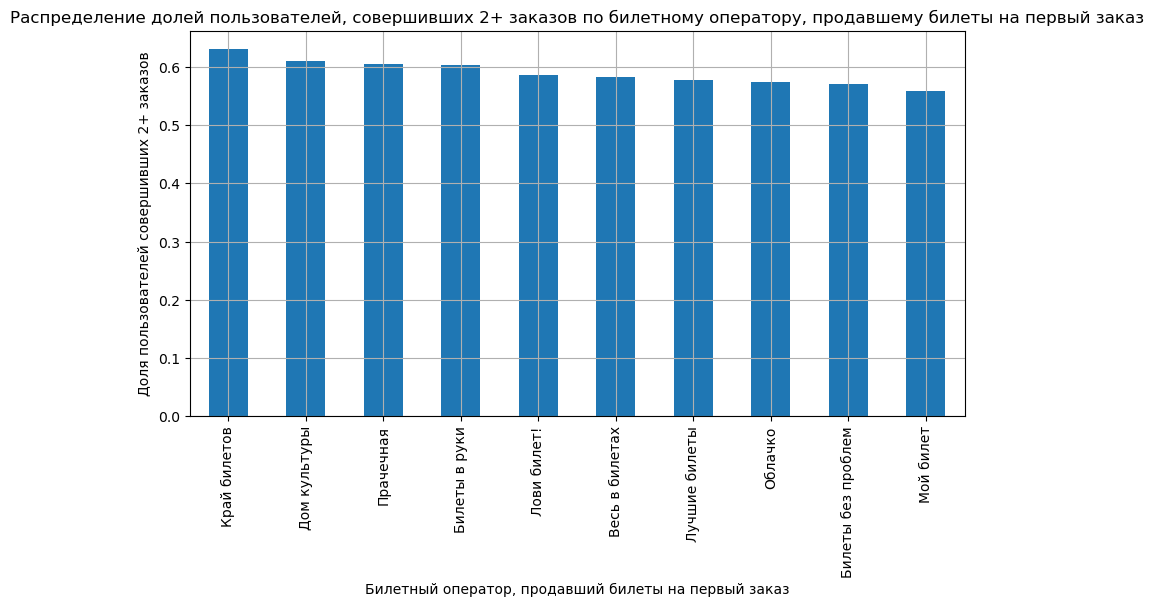

In [52]:
# Создаем урезанный датафрейм в соответствии с условием
pivot_service_name_is_two_cut = pivot_service_name_is_two.sort_values(by='users', ascending=False).head(10)

# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(10, 5))

# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
pivot_service_name_is_two_cut['share_True'].sort_values(ascending=False).plot(
               kind = 'bar', # Тип графика - столбчатая диаграмма
               rot = 90, # Градус вращения подписи по оси Х
               legend = False, # Выключаем легенду
               grid = True,
               title=f'Распределение долей пользователей, совершивших 2+ заказов по билетному оператору, продавшему билеты на первый заказ'
)

# Настраиваем оформление графика
plt.xlabel('Билетный оператор, продавший билеты на первый заказ')
plt.ylabel('Доля пользователей совершивших 2+ заказов')

# Выводим график
plt.show()

Сегменты пользователей, которые чаще возвращаются на Яндекс Афишу по типам (с учетом объема сегмента):
- по типу первого мероприятия - **в явном виде не определяются**
- по типу устройства, с которого совершена первая покупка - **в явном виде не определяются**
- по региону проведения мероприятия из первого заказа - **в явном виде не определяются**
- по билетному оператору, продавшему билеты на первый заказ - **Быстрый кассир**

Успешные «точки входа» — сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке в явном виде не прослеживаются. Доли возвращающихся на платформу во всех сегментах относительно стабильны.

#### 1.3. Проверка продуктовых гипотез:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс.Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
    - Исходя из результатов проведенного анализа, вероятность возврата на Яндекс.Афишу не зависит от типа первого мероприятия. Пользователи, первый раз купившие билет на спортивные мероприятия совершают повторный заказ не чаще, чем пользователи, оформившие свой первый заказ на концерты.
- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.
    - Исходя из результатов проведенного анализа, вероятность возврата на Яндекс.Афишу не зависит от региона первого мероприятия. В регионах, где больше всего пользователей впервые посещают мероприятия доля повторных заказов соизмерима с менее активными регионами.

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

    
* По выводам относительно гипотез все верно подмечено! Можно было бы еще сделать более яркий акцент на том, что в топ по повторным заказам вырвались регионы с ощутимо меньшим числом пользователей, а значит оценка показателя возвращаемости у них более чувствительна к колебаниям в количестве пользователей (1 дополнительный пользователь может существеннее повлиять на показатель, как в плюс, так и в минус).

</div>
<div class="alert alert-block alert-warning">📝
    

__Комментарий от ревьюера №1__

* Опять же, было бы не лишним дать понятное название подразделу и добавить пояснение к шагу.
    
    
* В случае вывода неполного набора сегментов стоит указать, какой процент от выборки они составляют, чтобы было понимание, насколько большая часть данных осталась за пределами нашего обзора.
    

    
* Также было бы неплохо добавить на графики линию среднего значения, чтобы было удобно сравнивать, какие сегменты и насколько отличаются от общего показателя по выборке. Это можно сделать с помощью `plt.axvline`, потребуется также добавить легенду.
    

* Выводы лучше подкреплять конкретными значениями (в данном случае количеством и долей), чтобы явно отразить, насколько велики эффекты, о которых мы говорим.

</div>

<div class="alert alert-info"> <b>Комментарии студента:</b> Ты имеешь в виду, что мало просто воспользоваться информацией предыдущих разделов, нужно еще и подкрепить расчетами почему?
    Я просто предположил, что "бизнесу" не так важны детали и, с учетом того, что выводы сделаны исходя из информации указанной выше, дополнительное повторение только "раздует" окончательный отчёт...
    Но всё равно спасибо, учту.
</div>

### 2. Исследование поведения пользователей через показатели выручки и состава заказа

#### 2.1. Изучение связи между средней выручкой сервиса с заказа и повторными заказами

Построим сравнительные гистограммы распределения средней выручки с билета ( avg_revenue_rub ):
- для пользователей, совершивших один заказ;
- для вернувшихся пользователей, совершивших 2 и более заказа.

Ответим на вопросы: 
- В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
- Есть ли различия между группами?

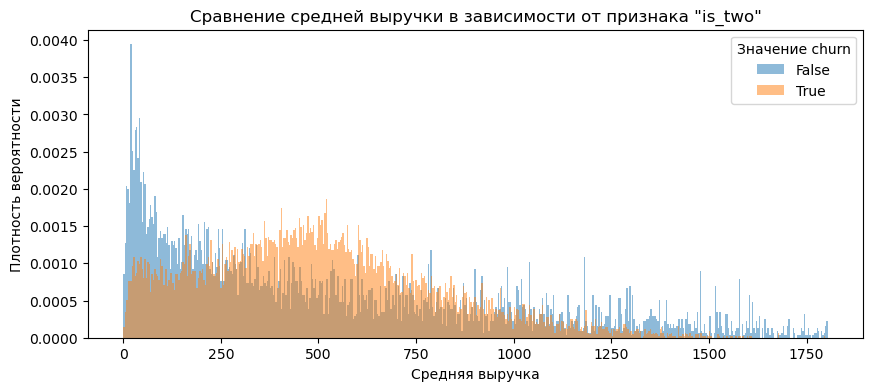

In [53]:
# Строим гистограмму распределения средней выручки
# Создаём фигуру графика
plt.figure(figsize=(10, 4))

# Строим гистограммы для каждого значения churn
for i in final_profile_filtered['is_two'].unique():
    # Фильтруем данные по значению столбца churn
    final_profile_filtered.loc[final_profile_filtered['is_two'] == i, 'avg_revenue'].plot(
        kind='hist',
        density=True,
        bins=500,
        alpha=0.5,
        label=f'{i}',
        legend=True
    )

# Настраиваем внешний вид графика и выводим его на экран
plt.title(f'Сравнение средней выручки в зависимости от признака "is_two"')
plt.xlabel('Средняя выручка')
plt.ylabel('Плотность вероятности')
plt.legend(title='Значение churn')

plt.show()

##### Средние выручки от заказов пользователей совершивщих один заказ и пользователей совершивих 2 и более заказов находятся в диапазоне 0 - 1 7500 рублей (без учета вылетов). 

Однако мода средней выручки для тех, кто делал 2 и более заказа находится правее моды заказавших 1 раз. Также график распределения средней выручки для совершивших 2 и более заказа выглядит более нормальным относительно распределения тех, кто заказал единожды. Этот график крайне левоцентричен.

**Вероятно стоит сделать вывод о том, что привлечение пользователей для повторных заказов повлияет на увеличение средней выручки с пользователя.**

<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__

Вот тут как раз видим на графике аномалии в 18к

<div class="alert alert-info"> <b>Комментарии студента:</b> С учётом исправления в разделах выше - уже нет :)
</div>

#### 2.2. Сравнение распределения по средней выручке с заказа для часто заказывающих пользователей

Сравним распределение по средней выручке с заказа в двух группах пользователей:
- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

Ответим на вопрос: 
- Есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

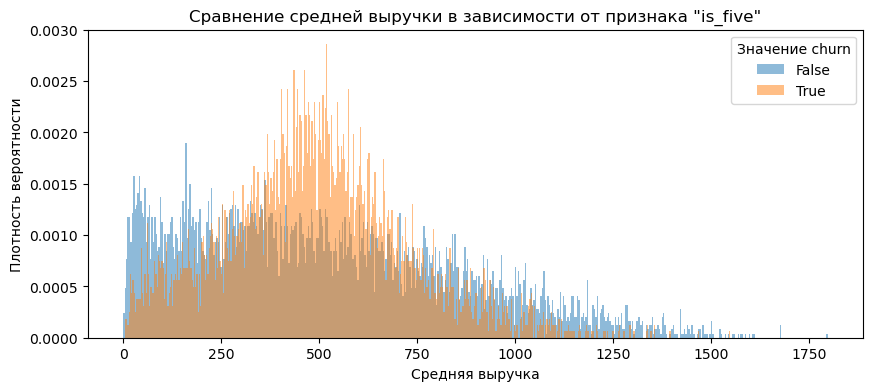

In [54]:
# Строим гистограмму распределения средней выручки
# Создаём фигуру графика
plt.figure(figsize=(10, 4))

# Строим гистограммы для каждого значения churn
for i in final_profile_filtered['is_five'].unique():
    # Фильтруем данные по значению столбца churn
    final_profile_filtered.loc[(final_profile_filtered['is_two'] == 1) & (final_profile_filtered['is_five'] == i), 'avg_revenue'].plot(
        kind='hist',
        density=True,
        bins=500,
        alpha=0.5,
        label=f'{i}',
        legend=True
    )

# Настраиваем внешний вид графика и выводим его на экран
plt.title(f'Сравнение средней выручки в зависимости от признака "is_five"')
plt.xlabel('Средняя выручка')
plt.ylabel('Плотность вероятности')
plt.legend(title='Значение churn')

plt.show()

Ситуация аналогична предыдущему графику. Мода средней выручки для тех, кто делал 5 и более заказа находится правее моды заказавших 2-4 раза.

**Это наводит на мысль о том, что чем больше заказов осуществляет пользователь, тем выше средняя выручка. А значит стоит работать над тем, чтобы увеличить количество заказов каждого пользователя.**

<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__

Вот тут как раз видим на графике аномалии в 18к

<div class="alert alert-info"> <b>Комментарии студента:</b> С учётом исправления в разделах выше - уже нет :)
</div>

#### 2.3. Анализ влияния среднего количества билетов в заказе на вероятность повторной покупки.

Изучим распределение пользователей по среднему количеству билетов в заказе ( avg_tickets_count ) и опишем основные наблюдения.

Разделим пользователей на несколько сегментов по среднему количеству билетов в заказе:
- от 1 до 2 билетов;
- от 2 до 3 билетов;
- от 3 до 5 билетов;
- от 5 и более билетов.
  
Для каждого сегмента подсчитаем общее число пользователей и долю пользователей, совершивших повторные заказы.

Ответим на вопросы:
- Как распределены пользователи по сегментам — равномерно или сконцентрировано?
- Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

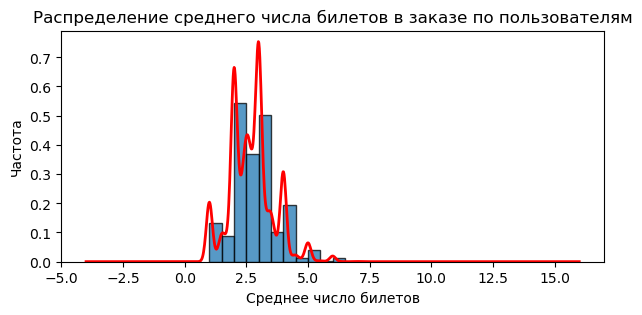

In [55]:
# Построим гистограмму распределения значений столбца 'tickets_count_mean'

# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 3))

# Строим гистограмму с помощью pandas через plot(kind='hist')
final_profile_filtered['avg_tickets'].plot(
                kind='hist', # Тип графика - гистограмма
                bins=20, # Устанавливаем количество корзин
                alpha=0.75,
                edgecolor='black',
                density=True,
                rot=0 # Градус вращения подписи по оси Х
)

# Добавляем линию KDE поверх гистограммы
final_profile_filtered['avg_tickets'].plot(
                kind='kde', 
                color='red',      # Цвет линии
                linewidth=2       # Толщина линии
)

# Настраиваем оформление графика
plt.title('Распределение среднего числа билетов в заказе по пользователям')
plt.xlabel('Среднее число билетов')
plt.ylabel('Частота')

# Выводим график
plt.show()

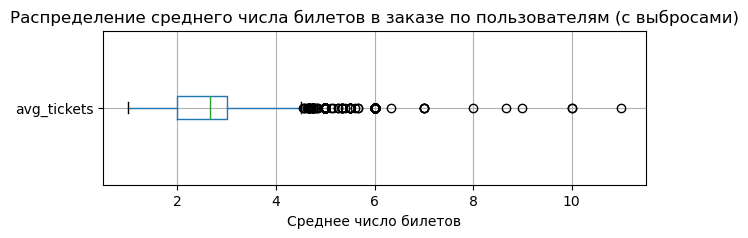

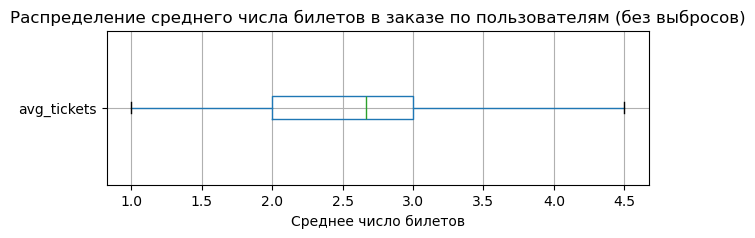

In [56]:
# Построим диаграмму размаха значений столбца 'tickets_count_mean'

# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 2))

# Строим диаграмму размаха значений в столбце middle_avg_bill с выбросами
final_profile_filtered.boxplot(column='avg_tickets', vert=False, showfliers=True)

# Добавляем заголовок и метки оси
plt.title('Распределение среднего числа билетов в заказе по пользователям (с выбросами)')
plt.xlabel('Среднее число билетов')

# Выводим график
plt.show()



# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 2))

# Строим диаграмму размаха значений в столбце middle_avg_bill без выбросов
final_profile_filtered.boxplot(column='avg_tickets', vert=False, showfliers=False)

# Добавляем заголовок и метки оси
plt.title('Распределение среднего числа билетов в заказе по пользователям (без выбросов)')
plt.xlabel('Среднее число билетов')

# Выводим график
plt.show()

Распределение значений среднего числа билетов по пользователям не характеризуются гигантскими выбросами, но график распределения также не описывает нормальное распределение (хотя похож), а имеет несколько пиков, что в такой характеристике допустимо.

Подобный внешний вид графика намекает на необходимость сегментации пользователей по количеству среднего количества билетов в заказе для проведения анализа и поиска аномалий.

In [57]:
# Группируем и считаем пользователей по среднему количеству билетов в заказе

final_profile_filtered_copy = final_profile_filtered.copy()

# Распределение на сегменты
final_profile_filtered_copy.loc[(final_profile_filtered_copy['avg_tickets'] >= 1) & (final_profile_filtered_copy['avg_tickets'] < 2), 'segment'] = '1-2 билета'
final_profile_filtered_copy.loc[(final_profile_filtered_copy['avg_tickets'] >= 2) & (final_profile_filtered_copy['avg_tickets'] < 3), 'segment'] = '2-3 билета'
final_profile_filtered_copy.loc[(final_profile_filtered_copy['avg_tickets'] >= 3) & (final_profile_filtered_copy['avg_tickets'] < 5), 'segment'] = '3-5 билетов'
final_profile_filtered_copy.loc[final_profile_filtered_copy['avg_tickets'] >= 5, 'segment'] = '5 и более билетов'

# Подсчёт количества и долей
segment_stats = final_profile_filtered_copy.groupby('segment').agg(count = ('user_id', 'count'), is_two = ('is_two', 'sum'))
segment_stats['share'] = (segment_stats['count'] / len(final_profile_filtered_copy)).round(2)
segment_stats['is_two_share'] = (segment_stats['is_two'] / segment_stats['count']).round(2)

print(segment_stats.sort_values(by='count', ascending=False))

                   count  is_two  share  is_two_share
segment                                              
2-3 билета          9498    6782   0.46          0.71
3-5 билетов         8425    4171   0.40          0.50
1-2 билета          2322    1078   0.11          0.46
5 и более билетов    573      68   0.03          0.12


Вывод метрик для 3-5 билетов
count    8425.000000
mean      630.642775
std       422.960882
min         0.240000
25%       277.920000
50%       574.430000
75%       927.920000
max      1804.410000
Name: avg_revenue, dtype: float64

Вывод метрик для 2-3 билета
count    9498.000000
mean      464.026768
std       292.575025
min         1.070000
25%       235.136500
50%       451.378333
75%       635.113750
max      1789.810000
Name: avg_revenue, dtype: float64

Вывод метрик для 1-2 билета
count    2322.000000
mean      247.336346
std       215.588411
min         0.070000
25%        70.042500
50%       205.592500
75%       358.596875
max      1716.101029
Name: avg_revenue, dtype: float64

Вывод метрик для 5 и более билетов
count     573.000000
mean      662.746927
std       494.720365
min         0.400000
25%       233.980000
50%       545.895000
75%      1043.460000
max      1802.230000
Name: avg_revenue, dtype: float64



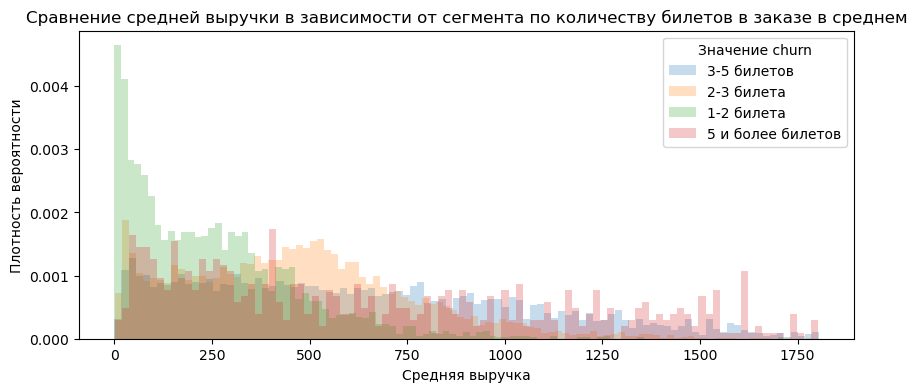

In [58]:
# Строим гистограмму распределения средней выручки
# Создаём фигуру графика
plt.figure(figsize=(10, 4))

# Строим гистограммы для каждого значения churn
for i in final_profile_filtered_copy['segment'].unique():
    final_profile_filtered_copy[final_profile_filtered_copy['segment'] == i]['avg_revenue'].plot(
        kind='hist',
        density=True,
        bins=100,
        alpha=0.25,
        label=f'{i}',
        legend=True
    )
    print(f'Вывод метрик для {i}')
    print(final_profile_filtered_copy[final_profile_filtered_copy['segment'] == i]['avg_revenue'].describe())
    print()

# Настраиваем внешний вид графика и выводим его на экран
plt.title(f'Сравнение средней выручки в зависимости от сегмента по количеству билетов в заказе в среднем')
plt.xlabel('Средняя выручка')
plt.ylabel('Плотность вероятности')
plt.legend(title='Значение churn')

plt.show()

Пользователи распределены по сегментам неравномерно. В выборка крайне мало пользователей, в заказе которых находится 1-2 билета и 5+ билетов (11 % и 3 % соответственно). В основном пользователи сконцентрированы в сегментах 2-3 билета и 3-5 билетов (43 % и 42 % соответственно).

Построив график распределения средней выручки данных по сегментам количества билетов в заказе, стоит отметить, что распределение тех, у кого 1-2 билета крайне левоцентрично и пик находится в районе 0, что может указывать на большой объем возврата покупок.

В выборке есть сегменты с аномально высокой или низкой долей повторных покупок:
- 2-3 билета - 73 % повторных покупок
- 5 и более билетов - 19 % повторных покупок

**По результатам анализа можно предположить, что стоит сконцентрироваться на привлечении пользователей, покупающих 2-3 билета, так как этот сегмент имеет наибольшее количество покупок и повторных покупок. Во втором приоритете можно рассматривать сегмент пользователей, покупающих 3-5 билетов по схожим но менее выраженным причинам.**

<div class="alert alert-block alert-warning">📝
    

__Комментарий от ревьюера №1__

Можно чуть структурировать интерпретацию. Начни с общего сравнения (чем отличаются группы в целом), затем подчеркни ключевые различия в диапазонах (например, что возвращающиеся чаще в зоне от...–до... ₽, а однократные имеют больший разброс), и завершай возможными причинами — например, что нулевая выручка у однократных, вероятно, связана с возвратами, а крупные заказы — с разовыми покупками для групп.
    
Еще можно добавить расчёты медины и среднего, чтобы понимать - имеется ли смещение и в какую сторону    

<div class="alert alert-info"> <b>Комментарии студента:</b> До меня доходило туго, но надеюсь я правильно понял, что ты имел в виду. Добавил, поправил вывод.
</div>

### 3. Исследование временных характеристик первого заказа и их влияния на повторные покупки

#### 3.1. Анализ влияния дня недели, в которой была совершена первая покупка, на поведение пользователей

По данным даты первого заказа выделим день недели.

Для каждого дня недели подсчитаем общее число пользователей и долю пользователей, совершивших повторные заказы. Визуализируем результаты.

Ответим на вопрос: 
- Влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

In [59]:
# Вычисляем столбец с наименованием дня недели
final_profile_filtered_copy = final_profile_filtered.copy()

final_profile_filtered_copy['first_order_weekday'] = final_profile_filtered_copy['first_order_date'].dt.day_name()

# Группируем и считаем пользователей по дню недели первого заказа, а также доли
first_order_weekday_grouped = final_profile_filtered_copy.groupby('first_order_weekday').agg(count = ('user_id', 'count'), is_two = ('is_two', 'sum'))
first_order_weekday_grouped['share'] = (first_order_weekday_grouped['count'] / len(final_profile_filtered_copy)).round(2)
first_order_weekday_grouped['is_two_share'] = (first_order_weekday_grouped['is_two'] / first_order_weekday_grouped['count']).round(2)

print(first_order_weekday_grouped)

                     count  is_two  share  is_two_share
first_order_weekday                                    
Friday                3157    1789   0.15          0.57
Monday                2746    1633   0.13          0.59
Saturday              3229    1948   0.16          0.60
Sunday                2718    1561   0.13          0.57
Thursday              3053    1728   0.15          0.57
Tuesday               2970    1721   0.14          0.58
Wednesday             2945    1719   0.14          0.58


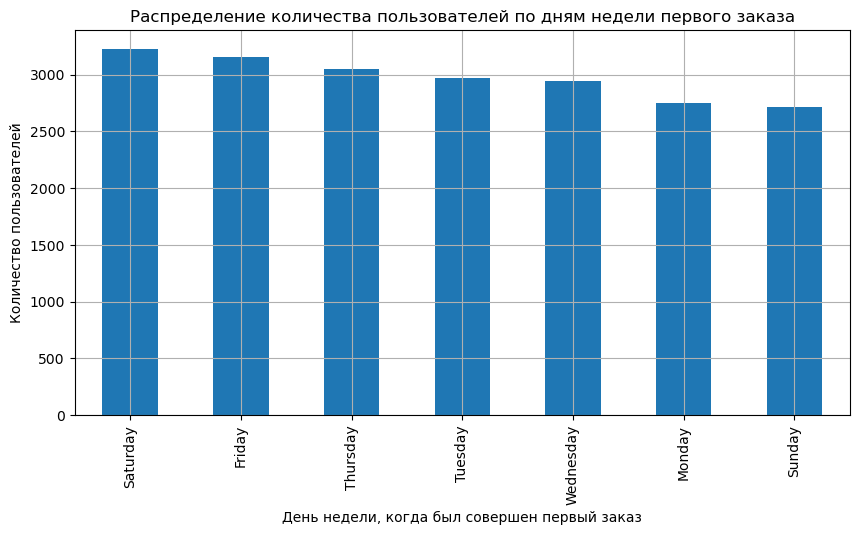

In [60]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(10, 5))

# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
first_order_weekday_grouped['count'].sort_values(ascending=False).plot(
               kind = 'bar', # Тип графика - столбчатая диаграмма
               rot = 90, # Градус вращения подписи по оси Х
               legend = False, # Выключаем легенду
               grid = True,
               title=f'Распределение количества пользователей по дням недели первого заказа'
)

# Настраиваем оформление графика
plt.xlabel('День недели, когда был совершен первый заказ')
plt.ylabel('Количество пользователей')

# Выводим график
plt.show()

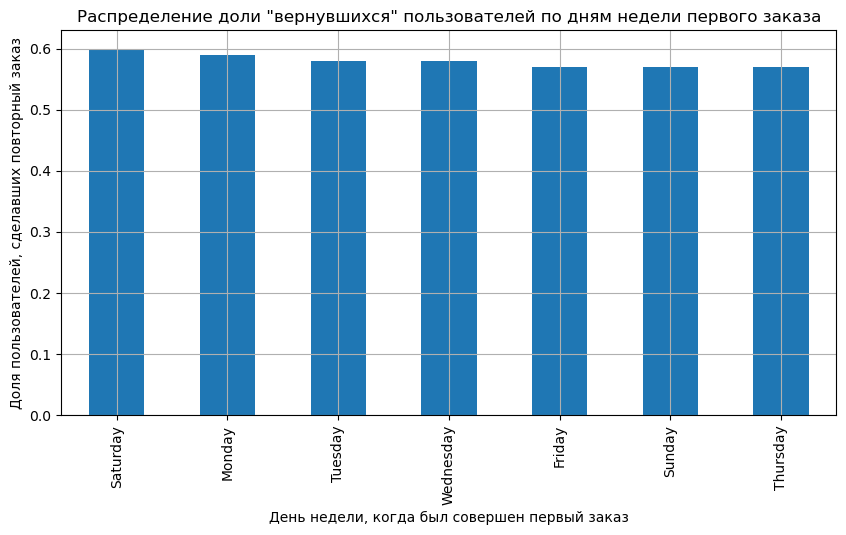

In [61]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(10, 5))

# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
first_order_weekday_grouped['is_two_share'].sort_values(ascending=False).plot(
               kind = 'bar', # Тип графика - столбчатая диаграмма
               rot = 90, # Градус вращения подписи по оси Х
               legend = False, # Выключаем легенду
               grid = True,
               title=f'Распределение доли "вернувшихся" пользователей по дням недели первого заказа'
)

# Настраиваем оформление графика
plt.xlabel('День недели, когда был совершен первый заказ')
plt.ylabel('Доля пользователей, сделавших повторный заказ')

# Выводим график
plt.show()

По результатам анализа информации можно с уверенностью сказать, что день недели, в который совершена первая покупка, на вероятность возврата клиента не влияет.

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

Когда планируют досуг, но возвращаемость остаётся примерно одинаковой — это говорит о том, что день недели первой покупки не влияет на лояльность, а повторное использование сервиса определяется скорее качеством опыта и интересом к мероприятиям

#### 3.2. Анализ влияния среднего интервала между заказами на удержание клиентов

Рассчитаем среднее время между заказами для двух групп пользователей:
- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

Исследуем, как средний интервал между заказами влияет на вероятность повторного заказа, и сделаем выводы.

In [62]:
# Группируем и считаем пользователей по количеству заказов

final_profile_filtered_copy = final_profile_filtered.copy()

# Распределение на сегменты
final_profile_filtered_copy.loc[(final_profile_filtered_copy['is_two'] == 1) & (final_profile_filtered_copy['is_five'] < 1), 'zakaz'] = '2–4 заказа'
final_profile_filtered_copy.loc[(final_profile_filtered_copy['is_five'] == 1), 'zakaz'] = '5 и более заказов'

# Подсчёт количества и долей
zakaz_stats = final_profile_filtered_copy.groupby('zakaz').agg(mean_days_between_order = ('avg_days_since_prev', 'mean'))

print(zakaz_stats.sort_values(by='mean_days_between_order', ascending=False))

                   mean_days_between_order
zakaz                                     
2–4 заказа                       23.688736
5 и более заказов                10.653158


C:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


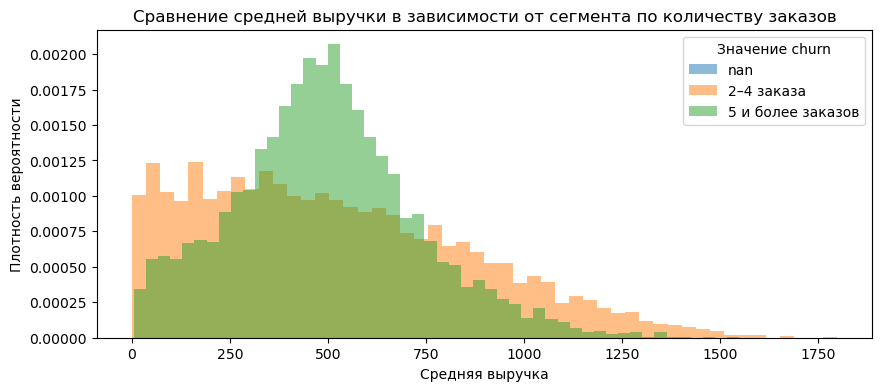

In [63]:
# Строим гистограмму распределения средней выручки
# Создаём фигуру графика
plt.figure(figsize=(10, 4))

# Строим гистограммы для каждого значения churn
for i in final_profile_filtered_copy['zakaz'].unique():
    final_profile_filtered_copy.loc[final_profile_filtered_copy['zakaz'] == i]['avg_revenue'].plot(
        kind='hist',
        density=True,
        bins=50,
        alpha=0.5,
        label=f'{i}',
        legend=True
    )

# Настраиваем внешний вид графика и выводим его на экран
plt.title(f'Сравнение средней выручки в зависимости от сегмента по количеству заказов')
plt.xlabel('Средняя выручка')
plt.ylabel('Плотность вероятности')
plt.legend(title='Значение churn')

plt.show()

Судя по диаграмме распределения, сильных выбросов не обнаружено

По результатам анализа можно сделать вывод о том, что средний интервал между заказами влияет на вероятность повторного заказа. Чем ниже интервал между заказами, тем больше заказов совершает пользователь в среднем.

**Следовательно стоит работать над тем, чтобы уменьшить интервал времени между заказами.**

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__
<b>Отлично ✅:</b> По расчетам все верно!
    
</div>
<div class="alert alert-block alert-warning">📝
    

__Комментарий от ревьюера №1__

<b>Рекомендации💡:</b>  Важно иметь в виду, что среднее значение довольно сильно зависит от характера распределения, если есть какие-то сильные выбросы, они могут утянуть среднее значение вверх, хотя основаня масса значений будет гораздо ниже. Поэтому здесь важно было бы построить в том числе гистограммы, наложить их друг на друга (как мы это делали при сравнении выручки), чтобы видеть всю картину в данных.
 
</div>

<div class="alert alert-info"> <b>Комментарии студента:</b> Добавил информацию. Скорректировал вывод.
</div>

### 4. Корреляционный анализ количества покупок и признаков пользователя

#### 4.1. Корреляционный анализ

Рассчитаем коэффициент корреляции phi_k между признаками профиля пользователя и числом заказов. 

Выделим сегменты пользователей:
- 1 заказ;
- от 2 до 4 заказов;
- от 5 и выше.
  
Визуализируем результат корреляции с помощью тепловой карты.

Ответим на вопрос: 
- Какие признаки наиболее связаны с количеством заказов?

In [64]:
# Вычисляем корреляционную матрицу с использованием phi_k
correlation_matrix = final_profile_filtered[['total_orders','avg_days_since_prev', 'avg_revenue', 'avg_tickets']].phik_matrix()

# Выводим результат
print(correlation_matrix)

interval columns not set, guessing: ['total_orders', 'avg_days_since_prev', 'avg_revenue', 'avg_tickets']
                     total_orders  avg_days_since_prev  avg_revenue  \
total_orders             1.000000             0.336741     0.279233   
avg_days_since_prev      0.336741             1.000000     0.116925   
avg_revenue              0.279233             0.116925     1.000000   
avg_tickets              0.238789             0.114847     0.430717   

                     avg_tickets  
total_orders            0.238789  
avg_days_since_prev     0.114847  
avg_revenue             0.430717  
avg_tickets             1.000000  


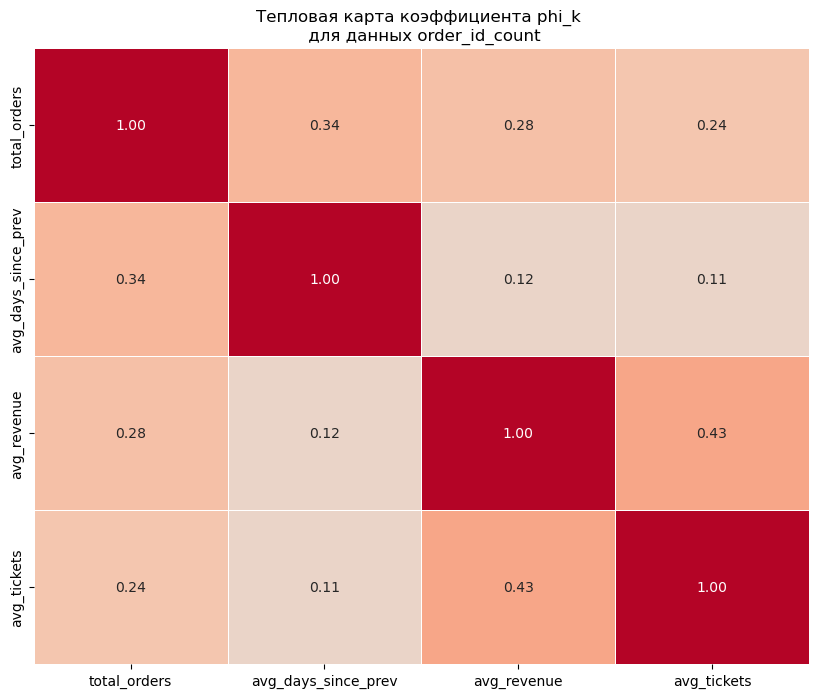

In [66]:
# Строим тепловую карту
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix,
            center=0,             # белый цвет в центре (ноль)
            vmin=-1, 
            vmax=1,
            annot=True, # Отображаем численные значения в ячейках карты
            fmt='.2f', # Форматируем значения корреляции: два знака после точки
            cmap='coolwarm', # Устанавливаем цветовую гамму от красного (макс. значение) к синему
            linewidths=0.5, # Форматируем линию между ячейками карты
            cbar=False # Отключаем цветовую шкалу
           )

# Добавляем заголовок и подпись по оси Х
plt.title('Тепловая карта коэффициента phi_k \n для данных order_id_count')

# Выводим график
plt.show()

In [67]:
# Группируем и считаем пользователей по количеству заказов

order_filtered_profile = final_profile_filtered.copy()

# Распределение на сегменты
order_filtered_profile.loc[(order_filtered_profile['total_orders'] == 1), 'segment'] = '1 заказ'
order_filtered_profile.loc[(order_filtered_profile['total_orders'] > 1) & (order_filtered_profile['total_orders'] <= 4), 'segment'] = 'от 2 до 4 заказов'
order_filtered_profile.loc[(order_filtered_profile['total_orders'] > 5), 'segment'] = '5 и более заказов'

# Вычисляем корреляционную матрицу с использованием phi_k
correlation_matrix1 = order_filtered_profile.loc[(order_filtered_profile['segment'] == '1 заказ')][['avg_days_since_prev', 'avg_revenue', 'avg_tickets']].phik_matrix()
correlation_matrix2 = order_filtered_profile.loc[(order_filtered_profile['segment'] == 'от 2 до 4 заказов')][['total_orders','avg_days_since_prev', 'avg_revenue', 'avg_tickets']].phik_matrix()
correlation_matrix3 = order_filtered_profile.loc[(order_filtered_profile['segment'] == '5 и более заказов')][['total_orders','avg_days_since_prev', 'avg_revenue', 'avg_tickets']].phik_matrix()

# Выводим результат
print(correlation_matrix1)
print()
print(correlation_matrix2)
print()
print(correlation_matrix3)

interval columns not set, guessing: ['avg_days_since_prev', 'avg_revenue', 'avg_tickets']
interval columns not set, guessing: ['total_orders', 'avg_days_since_prev', 'avg_revenue', 'avg_tickets']
interval columns not set, guessing: ['total_orders', 'avg_days_since_prev', 'avg_revenue', 'avg_tickets']
                     avg_days_since_prev  avg_revenue  avg_tickets
avg_days_since_prev             1.000000     0.488484     0.000000
avg_revenue                     0.488484     1.000000     0.434668
avg_tickets                     0.000000     0.434668     1.000000

                     total_orders  avg_days_since_prev  avg_revenue  \
total_orders             1.000000             0.392164     0.139954   
avg_days_since_prev      0.392164             1.000000     0.188307   
avg_revenue              0.139954             0.188307     1.000000   
avg_tickets              0.412501             0.118993     0.261882   

                     avg_tickets  
total_orders            0.412501  
avg

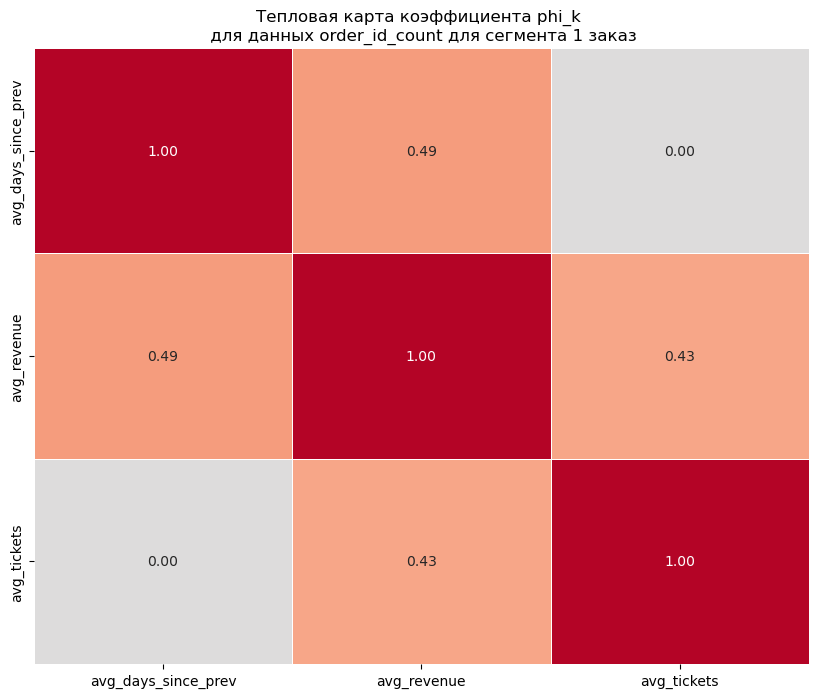

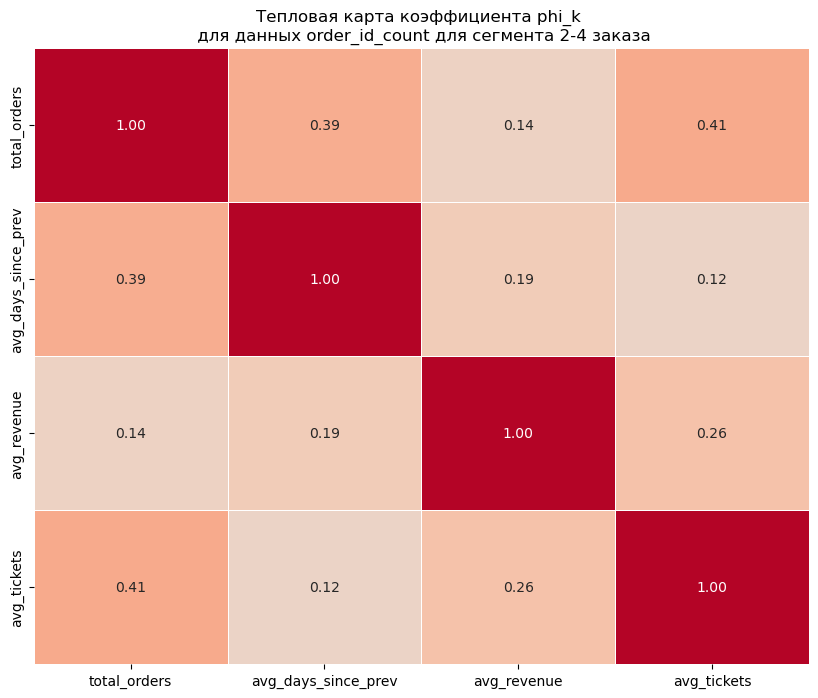

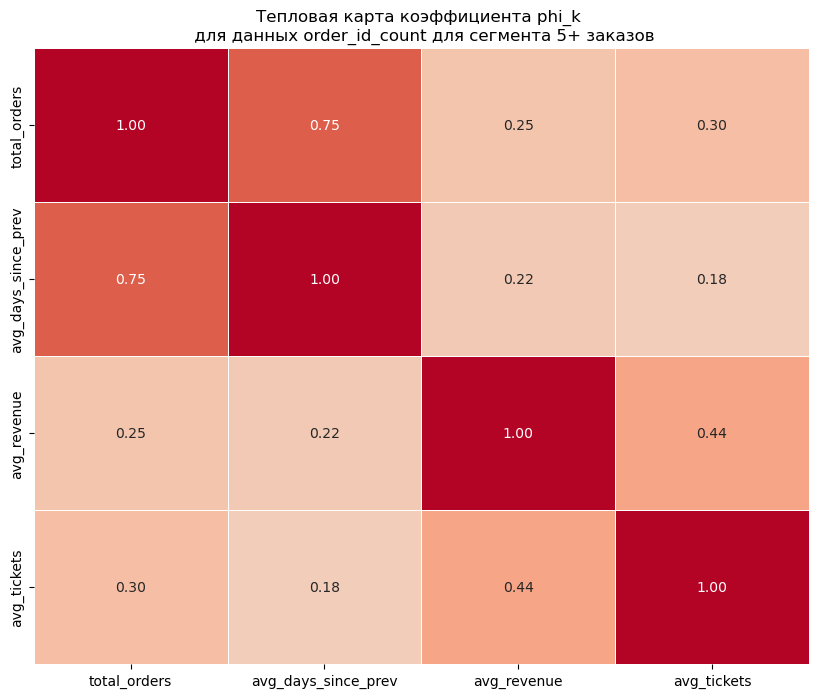

In [68]:
# Строим тепловую карту
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix1,
            center=0,             # белый цвет в центре (ноль)
            vmin=-1, 
            vmax=1,
            annot=True, # Отображаем численные значения в ячейках карты
            fmt='.2f', # Форматируем значения корреляции: два знака после точки
            cmap='coolwarm', # Устанавливаем цветовую гамму от красного (макс. значение) к синему
            linewidths=0.5, # Форматируем линию между ячейками карты
            cbar=False # Отключаем цветовую шкалу
           )

# Добавляем заголовок и подпись по оси Х
plt.title('Тепловая карта коэффициента phi_k \n для данных order_id_count для сегмента 1 заказ')

# Выводим график
plt.show()

# Строим тепловую карту
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix2,
            center=0,             # белый цвет в центре (ноль)
            vmin=-1, 
            vmax=1,
            annot=True, # Отображаем численные значения в ячейках карты
            fmt='.2f', # Форматируем значения корреляции: два знака после точки
            cmap='coolwarm', # Устанавливаем цветовую гамму от красного (макс. значение) к синему
            linewidths=0.5, # Форматируем линию между ячейками карты
            cbar=False # Отключаем цветовую шкалу
           )

# Добавляем заголовок и подпись по оси Х
plt.title('Тепловая карта коэффициента phi_k \n для данных order_id_count для сегмента 2-4 заказа')

# Выводим график
plt.show()

# Строим тепловую карту
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix3,
            center=0,             # белый цвет в центре (ноль)
            vmin=-1, 
            vmax=1,
            annot=True, # Отображаем численные значения в ячейках карты
            fmt='.2f', # Форматируем значения корреляции: два знака после точки
            cmap='coolwarm', # Устанавливаем цветовую гамму от красного (макс. значение) к синему
            linewidths=0.5, # Форматируем линию между ячейками карты
            cbar=False # Отключаем цветовую шкалу
           )

# Добавляем заголовок и подпись по оси Х
plt.title('Тепловая карта коэффициента phi_k \n для данных order_id_count для сегмента 5+ заказов')

# Выводим график
plt.show()

Исходя из результатов построения матриц корреляции можно констатировать, что наибольшая связь с количество заказов прослеживается у столбца, характеризующего среднее количество дней между заказами. При этом это характерно только для сегмента пользователей с 5+ заказами.

Также стоит отметить коррелляцию этого столбца с средней выручкой и средним количеством билетов у сегмента пользователей с 1 заказом.

**Вероятно стоит обратить внимание на работу с пользователями в части приложения усилий по сокращению интервалов времени между заказами, т.к. именно от этого показателя зависит и количество заказов и средний чек, если количество не велико. При этом стоит отдельно отметить, что исходя из результатов анализа можно уверенно заключить, что поведение клиентов во времени и количество билетов важнее для объяснения повторных покупок, чем их демография или первый выбор сервиса.**

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__
    
С этим заданием тоже справились!

</div>
<div class="alert alert-block alert-warning">📝
    

__Комментарий от ревьюера №1__


ются оценки, если сбалансировать разбиение на интервалы.
    
    
* Расцветку для тепловой карты имеет смысл выбирать трехцветную, если диапазон возможных значений от -1 до 1 (например, синий, белый, красный, белый при этом в нуле), или двухцветную, если от 0 до 1 (в 0 - белый, в 1 - красный). Поскольку на 0 будет нейтральный цвет, величину корреляции можно будет воспринимать через интенсивность цвета, а по самому цвету - положительная она или отрицательная.

    
* В выводах Было бы неплохо сделать более явный акцент на том, что поведение клиентов во времени и количество билетов важнее для объяснения повторных покупок, чем их демография или первый выбор сервиса.

</div>


<div class="alert alert-info"> <b>Комментарии студента:</b> Пардон, но часть твоих комментариев куда-то делась. Посмотрел в браузерной версии - то же самое. Напиши еще раз, плиз.

По тепловой карте - согласен, поправил.

Выводы поправил.
</div>

### 5. Общие выводы и рекомендации

#### Информация о данных

В рамках проведенного анализа был изучен датасет, содержащий информацию о 292 034 заказах 22 000 пользователей платформы Яндекс.Афиша за  весь летний период и два месяца осени 2024 года. Была проведена фильтрация данных по типу устройства, с которого был совершен заказ, выполнен расчет количество дней с предыдущего заказа пользователя. Информация о выручке была приведена к единой валюте - российскому рублю. Была проведена предобработка данных, в части фильтрации выбросов и оценка пропущенных значений. Проведено понижение разрядности части данных. 

#### Основные результаты анализа
- Всего в выборке 21 735 пользователей. Средняя выручка с одного заказа: 654.70 руб. Доля пользователей, совершивших 2 заказа: 61 %. Доля пользователей, совершивших 5 заказов: 29 %. Обцее число заказов: 287 806. Среднее число билетов в заказе: 2.75. 
- Успешные «точки входа» — сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке в явном виде не прослеживаются. Доли возвращающихся на платформу во всех сегментах относительно стабильны. Исходя из результатов проведенного анализа, вероятность возврата на Яндекс.Афишу не зависит от типа первого мероприятия.
- Средняя выручка и количество билетов в заказе напрямую связаны с вероятностью повторных покупок. Чем больше заказов осуществляет пользователь, тем выше средняя выручка
- День недели, в который совершена первая покупка, на вероятность возврата клиента не влияет. Средний интервал между заказами влияет на вероятность повторного заказа. Чем ниже интервал между заказами, тем больше заказов совершает пользователь в среднем.
- наибольшая связь с количество заказов прослеживается у столбца, характеризующего среднее количество дней между заказами. При этом это характерно только для сегмента пользователей с 5+ заказами. Также стоит отметить коррелляцию этого столбца с средней выручкой и средним количеством билетов у сегмента пользователей с 1 заказом.

#### Рекомендации для заказчика
- Стоит обратить внимание на то, что привлечение пользователей для повторных заказов повлияет на увеличение средней выручки с пользователя.
- С учетом того, что чем больше заказов осуществляет пользователь, тем выше средняя выручка, стоит работать над тем, чтобы увеличить количество заказов каждого пользователя.
- Можно предположить, что стоит сконцентрироваться на привлечении пользователей, покупающих 2-3 билета, так как этот сегмент имеет наибольшее количество покупок и повторных покупок. Во втором приоритете можно рассматривать сегмент пользователей, покупающих 3-5 билетов по схожим но менее выраженным причинам.
- Вывод о том, что средний интервал между заказами влияет на вероятность повторного заказа и чем ниже интервал между заказами, тем больше заказов совершает пользователь в среднем предполагает, что стоит обратить внимание на работу с пользователями в части приложения усилий по сокращению интервалов времени между заказами, т.к. именно от этого показателя зависит и количество заказов и средний чек, если количество не велико.

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__
    
С задачей справились! Все ключевые моменты отражены, что позволяет быстро ознакомиться с процессом работы и результатом, не вдаваясь в технический детали. Здорово, что завершаешь проект рекомендациями, основанные на выявленных закономерностях. Предложенные рекомендации логично следуют из анализа и могут быть непосредственно реализованы в маркетинговых стратегиях подогревания и удержания. 

</div>

*P.S. Исходя из задания - не понял, куда нужно вставить ссылку на GitHUB поэтому она появится здесь когда размещу: ССЫЛКА
(наверняка с первого раза проект не сдастся, так что пусть это будет мой технический долг после ревью)*

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

Договорились